In [18]:
import pandas as pd

movies = pd.read_csv("datasets/movies_directors/movies.csv", index_col=0).head(100)
directors = pd.read_csv("datasets/movies_directors/directors.csv", index_col=0).head(30)

df = movies.merge(directors, left_on="director_id", right_on="id", how="outer")

df.shape



(111, 14)

In [11]:
df

,id_x,budget,popularity,revenue,title,vote_average,vote_count,director_id,year,month,day,director_name,id_y,gender
0,43597,237000000,150,2787965087,Avatar,7.2,11800,4762,2009,Dec,Thursday,James Cameron,4762,Male
1,43598,300000000,139,961000000,Pirates of the Caribbean: At World's End,6.9,4500,4763,2007,May,Saturday,Gore Verbinski,4763,Male
2,43599,245000000,107,880674609,Spectre,6.3,4466,4764,2015,Oct,Monday,Sam Mendes,4764,Male
3,43600,250000000,112,1084939099,The Dark Knight Rises,7.6,9106,4765,2012,Jul,Monday,Christopher Nolan,4765,Male
4,43602,258000000,115,890871626,Spider-Man 3,5.9,3576,4767,2007,May,Tuesday,Sam Raimi,4767,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,48363,0,3,321952,The Last Waltz,7.9,64,4809,1978,May,Monday,Martin Scorsese,4809,Male
1461,48370,27000,19,3151130,Clerks,7.4,755,5369,1994,Sep,Tuesday,Kevin Smith,5369,Male
1462,48375,0,7,0,Rampage,6.0,131,5148,2009,Aug,Friday,Uwe Boll,5148,Male
1463,48376,0,3,0,Slacker,6.4,77,5535,1990,Jul,Friday,Richard Linklater,5535,Male


In [30]:
import pandas as pd

citations = pd.read_csv("datasets/deepscholar-bench/citations.csv")
paper_contents = pd.read_csv("datasets/deepscholar-bench/paper_content.csv")
print(paper_contents.columns)
print(citations.columns)

Index(['arxiv_link', 'arxiv_id', 'publication_date', 'paper_title', 'abstract',
       'related_works_section', 'related_works_length'],
      dtype='object')
Index(['parent_paper_title', 'parent_paper_arxiv_id', 'citation_shorthand',
       'raw_citation_text', 'cited_paper_title', 'cited_paper_arxiv_link',
       'cited_paper_abstract', 'has_metadata', 'is_arxiv_paper',
       'bib_paper_authors', 'bib_paper_year', 'bib_paper_month',
       'bib_paper_url', 'bib_paper_doi', 'bib_paper_journal'],
      dtype='object')


In [34]:
df1 = paper_contents.merge(citations, left_on="arxiv_id", right_on="parent_paper_arxiv_id", how="inner", indicator=True)[["arxiv_id", "paper_title", "parent_paper_arxiv_id", "parent_paper_title", "cited_paper_title"]]
df2 = df1.merge(paper_contents, left_on="cited_paper_title", right_on="paper_title", suffixes=("_x", "_y"), indicator=True)

df1.to_csv("temp.csv")

In [ ]:
cited_papers = pd.DataFrame(citations['cited_paper_title'])
print(cited_papers.shape)
cited_papers.drop_duplicates(subset=['cited_paper_title'], inplace=True)
print(cited_papers.shape)

sampled = cited_papers.sample(28)
print(sampled.shape)

df1 = citations.drop_duplicates(subset='cited_paper_title').merge(sampled, on="cited_paper_title", how="inner")
print(df1.shape)
df1.to_csv("temp.csv")

for size in 
sampled_papers = paper_contents.sample(10)

(1630, 1)
(1552, 1)
(28, 1)
(28, 15)


In [52]:
len(left_papers['arxiv_id'].tolist())

63

In [53]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("DeepPavlov/hwu64")

# Get the list of unique labels from the train split
unique_labels = sorted(set(dataset['train']['label']))

# Print them
for i, label in enumerate(unique_labels):
    print(f"{i+1}: {label}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/173k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/26.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8954 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1076 [00:00<?, ? examples/s]

1: 0
2: 1
3: 2
4: 3
5: 4
6: 5
7: 6
8: 7
9: 8
10: 9
11: 10
12: 11
13: 12
14: 13
15: 14
16: 15
17: 16
18: 17
19: 18
20: 19
21: 20
22: 21
23: 22
24: 23
25: 24
26: 25
27: 26
28: 27
29: 28
30: 29
31: 30
32: 31
33: 32
34: 33
35: 34
36: 35
37: 36
38: 37
39: 38
40: 39
41: 40
42: 41
43: 42
44: 43
45: 44
46: 45
47: 46
48: 47
49: 48
50: 49
51: 50
52: 51
53: 52
54: 53
55: 54
56: 55
57: 56
58: 57
59: 58
60: 59
61: 60
62: 61
63: 62
64: 63


In [ ]:
import pandas as pd 
movies = pd.read_csv("datasets/movies_directors/movies.csv", index_col=0)
directors = pd.read_csv("datasets/movies_directors/directors.csv", index_col=0)

df2 = movies.merge(directors, left_on="director_id", right_on="id", how="inner") 

directors_63 = df2['director_name'].head(63)

movies_1

0           James Cameron
1          Gore Verbinski
2              Sam Mendes
3       Christopher Nolan
4               Sam Raimi
              ...        
1460      Martin Scorsese
1461          Kevin Smith
1462             Uwe Boll
1463    Richard Linklater
1464     Robert Rodriguez
Name: director_name, Length: 1465, dtype: object

In [ ]:
import numpy as np

dir_indices = directors.index.to_list()
np.random.shuffle(dir_indices)
shuffled_directors = directors.loc[dir_indices].reset_index(drop=True).head(63)

merged_df = pd.merge(
    movies, 
    shuffled_directors, 
    left_on='director_id',  # Adjust this column name to match your movies csv
    right_on='id',          # Adjust this column name to match your directors csv/index name
    how='outer', 
    indicator=True          # <--- This creates the '_merge' column
)

matched_movies = merged_df[merged_df['_merge'] == 'both']
unmatched_movies = merged_df[merged_df['_merge'] == 'left_only']

print("Matched Movies Shape:", matched_movies.shape)
print("Unmatched Movies Shape:", unmatched_movies.shape)


size = 10

random_matched = matched_movies.sample(n=min(len(matched_movies), int(size/2)))
print(random_matched.shape)
random_unmatched = unmatched_movies.sample(n=min(len(unmatched_movies), int(size/2)))
print(random_unmatched.shape)


final_selection = pd.concat([random_matched, random_unmatched])[['title', 'director_name', '_merge']]

Matched Movies Shape: (77, 15)
Unmatched Movies Shape: (1388, 15)
(5, 15)
(5, 15)


In [32]:
final_selection

,title,director_name,_merge
1022,Ready to Rumble,Brian Robbins,both
1019,The Shaggy Dog,Brian Robbins,both
260,GoodFellas,Martin Scorsese,both
4,The Abyss,James Cameron,both
6,The Terminator,James Cameron,both
1184,28 Days Later,NaN,left_only
462,Now You See Me,NaN,left_only
1400,Bernie,NaN,left_only
1483,Saw IV,NaN,left_only
718,The Adventures of Ford Fairlane,NaN,left_only


In [1]:
import pandas as pd
import json

df_banking_data_categories = json.load(open("datasets/banking_data/categories.json", "r"))


In [6]:
categories = pd.DataFrame(df_banking_data_categories)
categories.rename(columns={0: 'category'}, inplace=True)
categories

,category
0,card_arrival
1,card_linking
2,exchange_rate
3,card_payment_wrong_exchange_rate
4,extra_charge_on_statement
...,...
72,cash_withdrawal_charge
73,card_about_to_expire
74,apple_pay_or_google_pay
75,verify_my_identity


In [7]:
from datasets import load_dataset

ds = load_dataset("google-research-datasets/go_emotions", "simplified")

README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [14]:
ds['test']['labels'][:100]

[[25],
 [0],
 [13],
 [15],
 [27],
 [15],
 [15],
 [15],
 [24],
 [25],
 [3, 10],
 [1, 18],
 [8],
 [0, 7],
 [14],
 [10],
 [14],
 [25, 27],
 [1],
 [15],
 [1],
 [24],
 [27],
 [27],
 [6, 27],
 [27],
 [0, 18],
 [27],
 [27],
 [7],
 [27],
 [27],
 [27],
 [20],
 [4, 27],
 [27],
 [27],
 [27],
 [27],
 [0, 1],
 [10],
 [5],
 [27],
 [27],
 [17, 26],
 [27],
 [1],
 [1],
 [27],
 [4],
 [27],
 [3, 10],
 [10, 27],
 [27],
 [14, 27],
 [27],
 [8],
 [27],
 [24],
 [15],
 [27],
 [18],
 [18],
 [27],
 [15],
 [25],
 [14],
 [6, 20],
 [9],
 [3],
 [3],
 [27],
 [27],
 [0, 1],
 [5, 20],
 [10, 18],
 [0, 22],
 [14],
 [4],
 [2, 3],
 [0],
 [20],
 [15],
 [7, 27],
 [3],
 [6],
 [10],
 [27],
 [0],
 [15],
 [7, 17],
 [10],
 [27],
 [22],
 [26],
 [27],
 [14],
 [13, 27],
 [27],
 [5, 18]]

In [ ]:
import pandas as pd


s = pd.read_csv("datasets/imdb_reviews/imdb_reviews.csv").head(50)['sentiment'].value_counts()
positive_count = s.get('positive', 0)
print(positive_count)

23


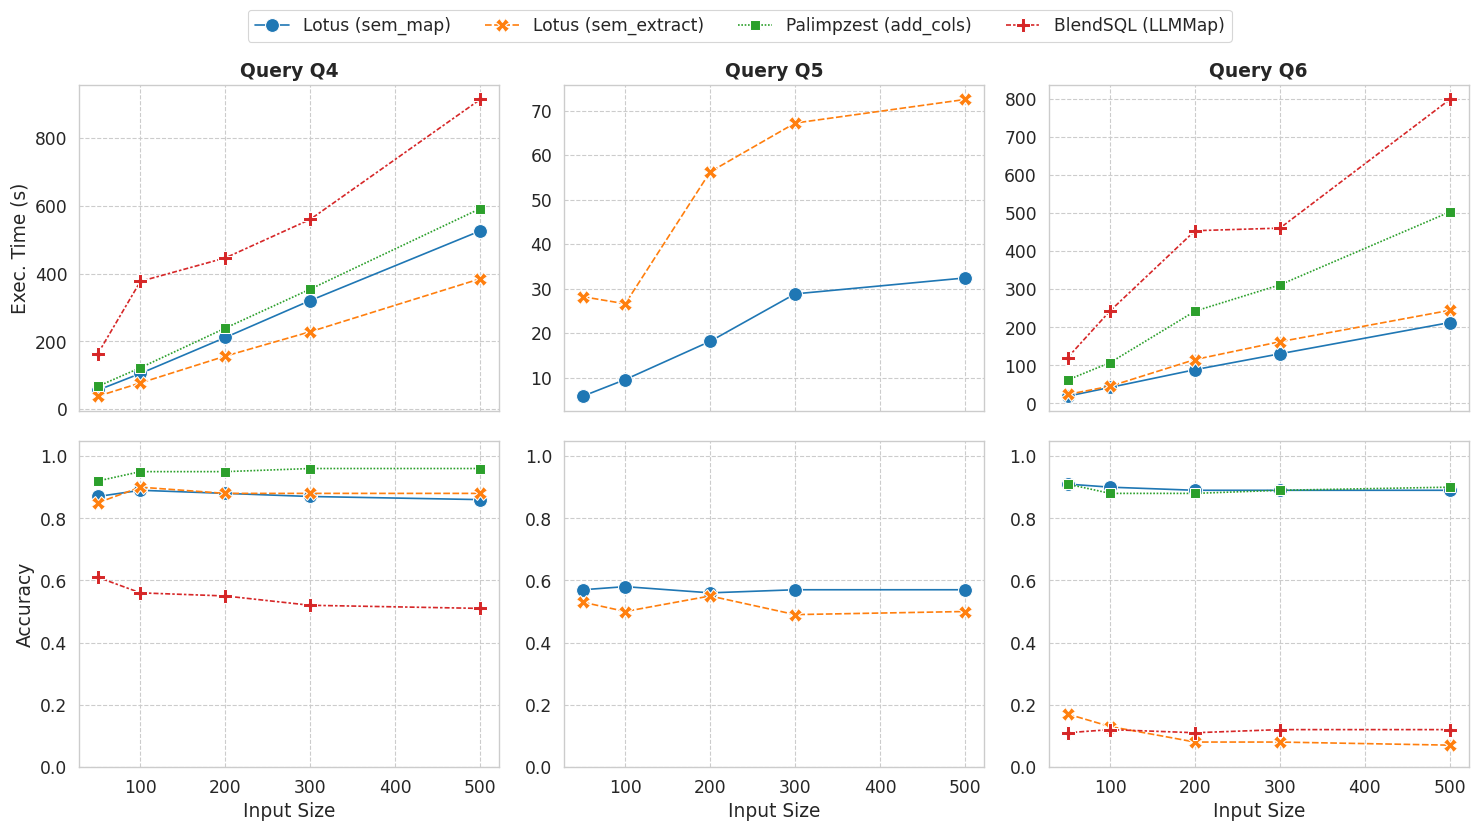

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare the data
data = [
    # Query | System | Op | Size | Time | Acc
    ["Q4", "Lotus", "sem_map", 50, 56.04, 0.87], ["Q4", "Lotus", "sem_map", 100, 105.14, 0.89],
    ["Q4", "Lotus", "sem_map", 200, 211.34, 0.88], ["Q4", "Lotus", "sem_map", 300, 320.37, 0.87],
    ["Q4", "Lotus", "sem_map", 500, 525.63, 0.86],
    ["Q4", "Lotus", "sem_extract", 50, 38.15, 0.85], ["Q4", "Lotus", "sem_extract", 100, 77.24, 0.90],
    ["Q4", "Lotus", "sem_extract", 200, 156.35, 0.88], ["Q4", "Lotus", "sem_extract", 300, 228.31, 0.88],
    ["Q4", "Lotus", "sem_extract", 500, 384.47, 0.88],
    ["Q4", "Palimpzest", "add_cols", 50, 67.35, 0.92], ["Q4", "Palimpzest", "add_cols", 100, 122.02, 0.95],
    ["Q4", "Palimpzest", "add_cols", 200, 239.00, 0.95], ["Q4", "Palimpzest", "add_cols", 300, 354.00, 0.96],
    ["Q4", "Palimpzest", "add_cols", 500, 591.39, 0.96],
    ["Q4", "BlendSQL", "LLMMap", 50, 163.92, 0.61], ["Q4", "BlendSQL", "LLMMap", 100, 376.88, 0.56],
    ["Q4", "BlendSQL", "LLMMap", 200, 446.07, 0.55], ["Q4", "BlendSQL", "LLMMap", 300, 559.78, 0.52],
    ["Q4", "BlendSQL", "LLMMap", 500, 913.36, 0.51],
    
    ["Q5", "Lotus", "sem_map", 50, 5.80, 0.57], ["Q5", "Lotus", "sem_map", 100, 9.54, 0.58],
    ["Q5", "Lotus", "sem_map", 200, 18.14, 0.56], ["Q5", "Lotus", "sem_map", 300, 28.81, 0.57],
    ["Q5", "Lotus", "sem_map", 500, 32.39, 0.57],
    ["Q5", "BlendSQL", "LLMMap", 50, 28.18, 0.53], ["Q5", "BlendSQL", "LLMMap", 100, 26.58, 0.50],
    ["Q5", "BlendSQL", "LLMMap", 200, 56.26, 0.55], ["Q5", "BlendSQL", "LLMMap", 300, 67.23, 0.49],
    ["Q5", "BlendSQL", "LLMMap", 500, 72.53, 0.50],

    ["Q6", "Lotus", "sem_map", 50, 19.18, 0.91], ["Q6", "Lotus", "sem_map", 100, 42.21, 0.90],
    ["Q6", "Lotus", "sem_map", 200, 88.74, 0.89], ["Q6", "Lotus", "sem_map", 300, 130.42, 0.89],
    ["Q6", "Lotus", "sem_map", 500, 212.42, 0.89],
    ["Q6", "Lotus", "sem_extract", 50, 23.72, 0.17], ["Q6", "Lotus", "sem_extract", 100, 45.30, 0.13],
    ["Q6", "Lotus", "sem_extract", 200, 115.33, 0.08], ["Q6", "Lotus", "sem_extract", 300, 162.15, 0.08],
    ["Q6", "Lotus", "sem_extract", 500, 244.53, 0.07],
    ["Q6", "Palimpzest", "add_cols", 50, 61.85, 0.91], ["Q6", "Palimpzest", "add_cols", 100, 107.19, 0.88],
    ["Q6", "Palimpzest", "add_cols", 200, 242.33, 0.88], ["Q6", "Palimpzest", "add_cols", 300, 311.36, 0.89],
    ["Q6", "Palimpzest", "add_cols", 500, 502.61, 0.90],
    ["Q6", "BlendSQL", "LLMMap", 50, 120.44, 0.11], ["Q6", "BlendSQL", "LLMMap", 100, 242.98, 0.12],
    ["Q6", "BlendSQL", "LLMMap", 200, 453.40, 0.11], ["Q6", "BlendSQL", "LLMMap", 300, 460.19, 0.12],
    ["Q6", "BlendSQL", "LLMMap", 500, 797.71, 0.12],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# 2. Set Plotting Style
sns.set_context("paper", font_scale=1.4)
sns.set_style("whitegrid", {'grid.linestyle': '--'})
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

queries = ["Q4", "Q5", "Q6"]
metrics = ["Time", "Accuracy"]
y_labels = ["Exec. Time (s)", "Accuracy"]

for col, q in enumerate(queries):
    q_df = df[df["Query"] == q]
    
    # Row 0: Execution Time
    sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", 
                 style="Label", markers=True, markersize=10, ax=axes[0, col], legend=(col == 2))
    axes[0, col].set_title(f"Query {q}", fontweight='bold')
    axes[0, col].set_ylabel(y_labels[0] if col == 0 else "")
    axes[0, col].set_xlabel("")

    # Row 1: Accuracy
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", 
                 style="Label", markers=True, markersize=10, ax=axes[1, col], legend=False)
    axes[1, col].set_ylim(0, 1.05)
    axes[1, col].set_ylabel(y_labels[1] if col == 0 else "")
    axes[1, col].set_xlabel("Input Size")

# Legend adjustments
handles, labels = axes[0, 2].get_legend_handles_labels()
axes[0, 2].legend().remove()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=True)

plt.tight_layout()
plt.show()

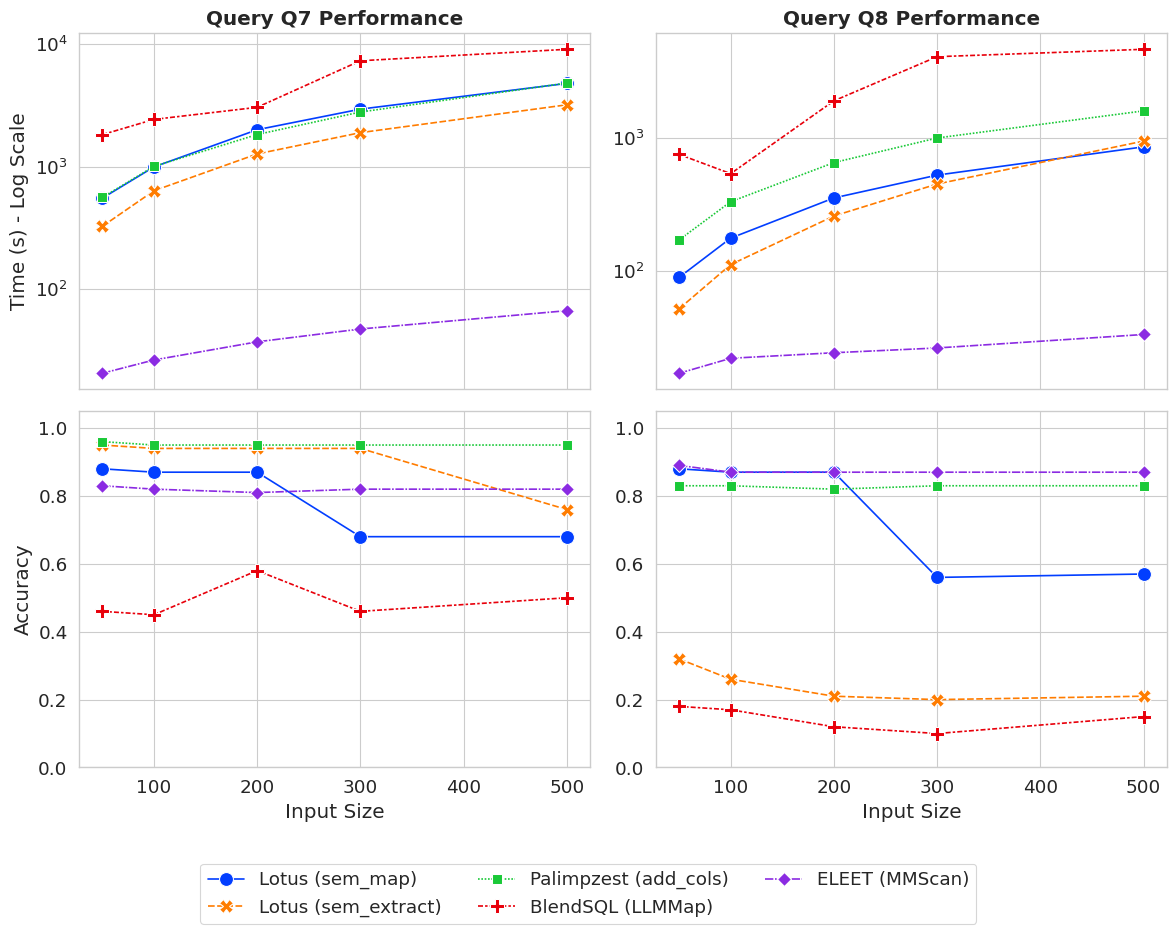

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare the data
# Format: [Query, System, Operator, Size, Time, F1, Accuracy]
data = [
    # Q7 Data
    ["Q7", "Lotus", "sem_map", 50, 552.77, 1.00, 0.88], ["Q7", "Lotus", "sem_map", 100, 993.76, 1.00, 0.87],
    ["Q7", "Lotus", "sem_map", 200, 2000.09, 1.00, 0.87], ["Q7", "Lotus", "sem_map", 300, 2944.63, 1.00, 0.68],
    ["Q7", "Lotus", "sem_map", 500, 4774.96, 1.00, 0.68],
    ["Q7", "Lotus", "sem_extract", 50, 325.53, 1.00, 0.95], ["Q7", "Lotus", "sem_extract", 100, 635.13, 0.99, 0.94],
    ["Q7", "Lotus", "sem_extract", 200, 1269.23, 0.99, 0.94], ["Q7", "Lotus", "sem_extract", 300, 1893.17, 0.99, 0.94],
    ["Q7", "Lotus", "sem_extract", 500, 3193.82, 0.99, 0.76],
    ["Q7", "Palimpzest", "add_cols", 50, 560.28, 1.00, 0.96], ["Q7", "Palimpzest", "add_cols", 100, 1004.26, 1.00, 0.95],
    ["Q7", "Palimpzest", "add_cols", 200, 1827.41, 1.00, 0.95], ["Q7", "Palimpzest", "add_cols", 300, 2790.05, 1.00, 0.95],
    ["Q7", "Palimpzest", "add_cols", 500, 4805.79, 1.00, 0.95],
    ["Q7", "BlendSQL", "LLMMap", 50, 1823.89, 0.95, 0.46], ["Q7", "BlendSQL", "LLMMap", 100, 2427.90, 0.94, 0.45],
    ["Q7", "BlendSQL", "LLMMap", 200, 3046.68, 0.08, 0.58], ["Q7", "BlendSQL", "LLMMap", 300, 7305.57, 0.84, 0.46],
    ["Q7", "BlendSQL", "LLMMap", 500, 9062.82, 0.13, 0.50],
    ["Q7", "ELEET", "MMScan", 50, 20.60, 0.83, 0.83], ["Q7", "ELEET", "MMScan", 100, 26.45, 0.81, 0.82],
    ["Q7", "ELEET", "MMScan", 200, 37.19, 0.81, 0.81], ["Q7", "ELEET", "MMScan", 300, 47.33, 0.82, 0.82],
    ["Q7", "ELEET", "MMScan", 500, 66.82, 0.81, 0.82],

    # Q8 Data
    ["Q8", "Lotus", "sem_map", 50, 89.09, 0.99, 0.88], ["Q8", "Lotus", "sem_map", 100, 175.56, 0.98, 0.87],
    ["Q8", "Lotus", "sem_map", 200, 351.76, 0.99, 0.87], ["Q8", "Lotus", "sem_map", 300, 522.03, 0.99, 0.56],
    ["Q8", "Lotus", "sem_map", 500, 851.00, 0.98, 0.57],
    ["Q8", "Lotus", "sem_extract", 50, 51.76, 0.37, 0.32], ["Q8", "Lotus", "sem_extract", 100, 111.15, 0.28, 0.26],
    ["Q8", "Lotus", "sem_extract", 200, 257.47, 0.25, 0.21], ["Q8", "Lotus", "sem_extract", 300, 447.67, 0.23, 0.20],
    ["Q8", "Lotus", "sem_extract", 500, 940.20, 0.21, 0.21],
    ["Q8", "Palimpzest", "add_cols", 50, 170.22, 1.00, 0.83], ["Q8", "Palimpzest", "add_cols", 100, 329.60, 0.99, 0.83],
    ["Q8", "Palimpzest", "add_cols", 200, 648.29, 0.98, 0.82], ["Q8", "Palimpzest", "add_cols", 300, 991.81, 0.98, 0.83],
    ["Q8", "Palimpzest", "add_cols", 500, 1584.21, 0.97, 0.83],
    ["Q8", "BlendSQL", "LLMMap", 50, 747.19, 0.20, 0.18], ["Q8", "BlendSQL", "LLMMap", 100, 535.47, 0.57, 0.17],
    ["Q8", "BlendSQL", "LLMMap", 200, 1884.79, 0.51, 0.12], ["Q8", "BlendSQL", "LLMMap", 300, 4043.17, 0.59, 0.10],
    ["Q8", "BlendSQL", "LLMMap", 500, 4594.27, 0.19, 0.15],
    ["Q8", "ELEET", "MMScan", 50, 16.98, 0.87, 0.89], ["Q8", "ELEET", "MMScan", 100, 22.01, 0.83, 0.87],
    ["Q8", "ELEET", "MMScan", 200, 24.22, 0.88, 0.87], ["Q8", "ELEET", "MMScan", 300, 26.30, 0.86, 0.87],
    ["Q8", "ELEET", "MMScan", 500, 33.21, 0.85, 0.87],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "F1", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# 2. Plotting
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

queries = ["Q7", "Q8"]
palette = sns.color_palette("bright", n_colors=df["Label"].nunique())

for i, q in enumerate(queries):
    q_df = df[df["Query"] == q]
    
    # ROW 0: Time (LOG SCALE)
    lp = sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", style="Label", 
                 markers=True, markersize=10, ax=axes[0, i], palette=palette, legend=(i==0))
    axes[0, i].set_yscale('log')
    axes[0, i].set_title(f"Query {q} Performance", fontweight='bold')
    axes[0, i].set_ylabel("Time (s) - Log Scale" if i==0 else "")
    
    # ROW 1: Accuracy
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
                 markers=True, markersize=10, ax=axes[1, i], palette=palette, legend=False)
    axes[1, i].set_ylim(0, 1.05)
    axes[1, i].set_ylabel("Accuracy" if i==0 else "")
    axes[1, i].set_xlabel("Input Size")

# Handle Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

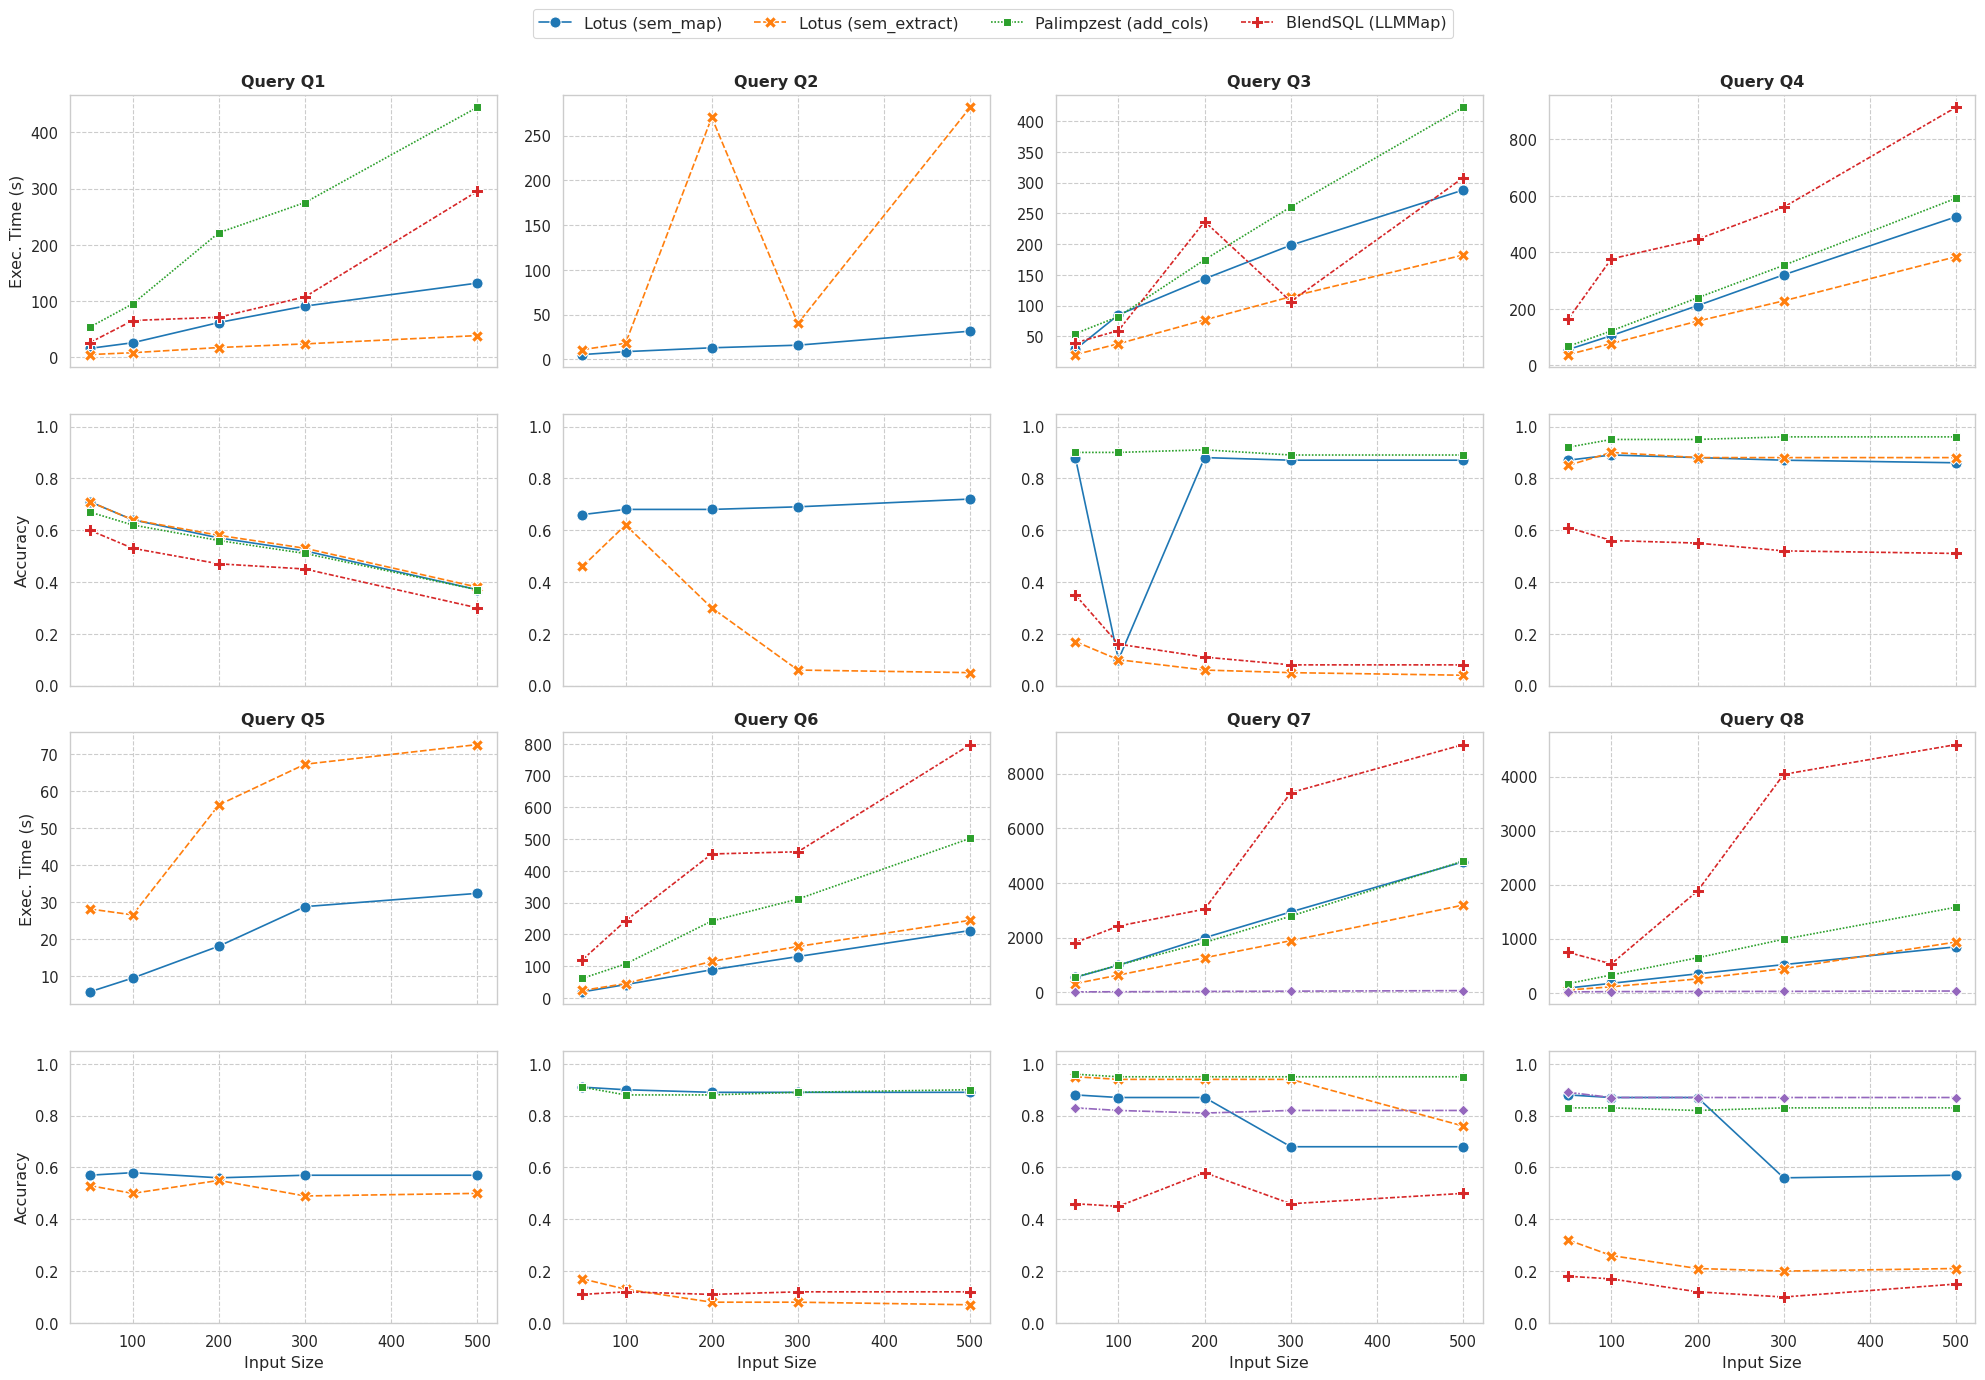

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare the data from LaTeX tables
data = [
    # Query, System, Op, Size, Time, Acc
    # Q1
    ["Q1", "Lotus", "sem_map", 50, 15.92, 0.71], ["Q1", "Lotus", "sem_map", 100, 25.98, 0.64], ["Q1", "Lotus", "sem_map", 200, 61.93, 0.57], ["Q1", "Lotus", "sem_map", 300, 91.12, 0.52], ["Q1", "Lotus", "sem_map", 500, 132.00, 0.37],
    ["Q1", "Lotus", "sem_extract", 50, 4.96, 0.71], ["Q1", "Lotus", "sem_extract", 100, 8.27, 0.64], ["Q1", "Lotus", "sem_extract", 200, 17.49, 0.58], ["Q1", "Lotus", "sem_extract", 300, 23.95, 0.53], ["Q1", "Lotus", "sem_extract", 500, 38.70, 0.38],
    ["Q1", "Palimpzest", "add_cols", 50, 53.46, 0.67], ["Q1", "Palimpzest", "add_cols", 100, 95.07, 0.62], ["Q1", "Palimpzest", "add_cols", 200, 221.50, 0.56], ["Q1", "Palimpzest", "add_cols", 300, 275.17, 0.51], ["Q1", "Palimpzest", "add_cols", 500, 444.43, 0.37],
    ["Q1", "BlendSQL", "LLMMap", 50, 25.97, 0.60], ["Q1", "BlendSQL", "LLMMap", 100, 65.49, 0.53], ["Q1", "BlendSQL", "LLMMap", 200, 71.32, 0.47], ["Q1", "BlendSQL", "LLMMap", 300, 107.55, 0.45], ["Q1", "BlendSQL", "LLMMap", 500, 295.20, 0.30],
    # Q2
    ["Q2", "Lotus", "sem_map", 50, 5.44, 0.66], ["Q2", "Lotus", "sem_map", 100, 8.71, 0.68], ["Q2", "Lotus", "sem_map", 200, 13.02, 0.68], ["Q2", "Lotus", "sem_map", 300, 15.94, 0.69], ["Q2", "Lotus", "sem_map", 500, 31.60, 0.72],
    ["Q2", "BlendSQL", "LLMMap", 50, 10.97, 0.46], ["Q2", "BlendSQL", "LLMMap", 100, 18.01, 0.62], ["Q2", "BlendSQL", "LLMMap", 200, 270.40, 0.30], ["Q2", "BlendSQL", "LLMMap", 300, 40.17, 0.06], ["Q2", "BlendSQL", "LLMMap", 500, 281.75, 0.05],
    # Q3
    ["Q3", "Lotus", "sem_map", 50, 29.11, 0.88], ["Q3", "Lotus", "sem_map", 100, 85.20, 0.10], ["Q3", "Lotus", "sem_map", 200, 143.76, 0.88], ["Q3", "Lotus", "sem_map", 300, 198.36, 0.87], ["Q3", "Lotus", "sem_map", 500, 288.03, 0.87],
    ["Q3", "Lotus", "sem_extract", 50, 20.61, 0.17], ["Q3", "Lotus", "sem_extract", 100, 38.19, 0.10], ["Q3", "Lotus", "sem_extract", 200, 76.95, 0.06], ["Q3", "Lotus", "sem_extract", 300, 114.73, 0.05], ["Q3", "Lotus", "sem_extract", 500, 182.36, 0.04],
    ["Q3", "Palimpzest", "add_cols", 50, 54.77, 0.90], ["Q3", "Palimpzest", "add_cols", 100, 82.38, 0.90], ["Q3", "Palimpzest", "add_cols", 200, 174.79, 0.91], ["Q3", "Palimpzest", "add_cols", 300, 260.63, 0.89], ["Q3", "Palimpzest", "add_cols", 500, 422.58, 0.89],
    ["Q3", "BlendSQL", "LLMMap", 50, 39.70, 0.35], ["Q3", "BlendSQL", "LLMMap", 100, 59.69, 0.16], ["Q3", "BlendSQL", "LLMMap", 200, 236.87, 0.11], ["Q3", "BlendSQL", "LLMMap", 300, 106.85, 0.08], ["Q3", "BlendSQL", "LLMMap", 500, 308.09, 0.08],
    # Q4
    ["Q4", "Lotus", "sem_map", 50, 56.04, 0.87], ["Q4", "Lotus", "sem_map", 100, 105.14, 0.89], ["Q4", "Lotus", "sem_map", 200, 211.34, 0.88], ["Q4", "Lotus", "sem_map", 300, 320.37, 0.87], ["Q4", "Lotus", "sem_map", 500, 525.63, 0.86],
    ["Q4", "Lotus", "sem_extract", 50, 38.15, 0.85], ["Q4", "Lotus", "sem_extract", 100, 77.24, 0.90], ["Q4", "Lotus", "sem_extract", 200, 156.35, 0.88], ["Q4", "Lotus", "sem_extract", 300, 228.31, 0.88], ["Q4", "Lotus", "sem_extract", 500, 384.47, 0.88],
    ["Q4", "Palimpzest", "add_cols", 50, 67.35, 0.92], ["Q4", "Palimpzest", "add_cols", 100, 122.02, 0.95], ["Q4", "Palimpzest", "add_cols", 200, 239.00, 0.95], ["Q4", "Palimpzest", "add_cols", 300, 354.00, 0.96], ["Q4", "Palimpzest", "add_cols", 500, 591.39, 0.96],
    ["Q4", "BlendSQL", "LLMMap", 50, 163.92, 0.61], ["Q4", "BlendSQL", "LLMMap", 100, 376.88, 0.56], ["Q4", "BlendSQL", "LLMMap", 200, 446.07, 0.55], ["Q4", "BlendSQL", "LLMMap", 300, 559.78, 0.52], ["Q4", "BlendSQL", "LLMMap", 500, 913.36, 0.51],
    # Q5
    ["Q5", "Lotus", "sem_map", 50, 5.80, 0.57], ["Q5", "Lotus", "sem_map", 100, 9.54, 0.58], ["Q5", "Lotus", "sem_map", 200, 18.14, 0.56], ["Q5", "Lotus", "sem_map", 300, 28.81, 0.57], ["Q5", "Lotus", "sem_map", 500, 32.39, 0.57],
    ["Q5", "BlendSQL", "LLMMap", 50, 28.18, 0.53], ["Q5", "BlendSQL", "LLMMap", 100, 26.58, 0.50], ["Q5", "BlendSQL", "LLMMap", 200, 56.26, 0.55], ["Q5", "BlendSQL", "LLMMap", 300, 67.23, 0.49], ["Q5", "BlendSQL", "LLMMap", 500, 72.53, 0.50],
    # Q6
    ["Q6", "Lotus", "sem_map", 50, 19.18, 0.91], ["Q6", "Lotus", "sem_map", 100, 42.21, 0.90], ["Q6", "Lotus", "sem_map", 200, 88.74, 0.89], ["Q6", "Lotus", "sem_map", 300, 130.42, 0.89], ["Q6", "Lotus", "sem_map", 500, 212.42, 0.89],
    ["Q6", "Lotus", "sem_extract", 50, 23.72, 0.17], ["Q6", "Lotus", "sem_extract", 100, 45.30, 0.13], ["Q6", "Lotus", "sem_extract", 200, 115.33, 0.08], ["Q6", "Lotus", "sem_extract", 300, 162.15, 0.08], ["Q6", "Lotus", "sem_extract", 500, 244.53, 0.07],
    ["Q6", "Palimpzest", "add_cols", 50, 61.85, 0.91], ["Q6", "Palimpzest", "add_cols", 100, 107.19, 0.88], ["Q6", "Palimpzest", "add_cols", 200, 242.33, 0.88], ["Q6", "Palimpzest", "add_cols", 300, 311.36, 0.89], ["Q6", "Palimpzest", "add_cols", 500, 502.61, 0.90],
    ["Q6", "BlendSQL", "LLMMap", 50, 120.44, 0.11], ["Q6", "BlendSQL", "LLMMap", 100, 242.98, 0.12], ["Q6", "BlendSQL", "LLMMap", 200, 453.40, 0.11], ["Q6", "BlendSQL", "LLMMap", 300, 460.19, 0.12], ["Q6", "BlendSQL", "LLMMap", 500, 797.71, 0.12],
    # Q7
    ["Q7", "Lotus", "sem_map", 50, 552.77, 0.88], ["Q7", "Lotus", "sem_map", 100, 993.76, 0.87], ["Q7", "Lotus", "sem_map", 200, 2000.09, 0.87], ["Q7", "Lotus", "sem_map", 300, 2944.63, 0.68], ["Q7", "Lotus", "sem_map", 500, 4774.96, 0.68],
    ["Q7", "Lotus", "sem_extract", 50, 325.53, 0.95], ["Q7", "Lotus", "sem_extract", 100, 635.13, 0.94], ["Q7", "Lotus", "sem_extract", 200, 1269.23, 0.94], ["Q7", "Lotus", "sem_extract", 300, 1893.17, 0.94], ["Q7", "Lotus", "sem_extract", 500, 3193.82, 0.76],
    ["Q7", "Palimpzest", "add_cols", 50, 560.28, 0.96], ["Q7", "Palimpzest", "add_cols", 100, 1004.26, 0.95], ["Q7", "Palimpzest", "add_cols", 200, 1827.41, 0.95], ["Q7", "Palimpzest", "add_cols", 300, 2790.05, 0.95], ["Q7", "Palimpzest", "add_cols", 500, 4805.79, 0.95],
    ["Q7", "BlendSQL", "LLMMap", 50, 1823.89, 0.46], ["Q7", "BlendSQL", "LLMMap", 100, 2427.90, 0.45], ["Q7", "BlendSQL", "LLMMap", 200, 3046.68, 0.58], ["Q7", "BlendSQL", "LLMMap", 300, 7305.57, 0.46], ["Q7", "BlendSQL", "LLMMap", 500, 9062.82, 0.50],
    ["Q7", "ELEET", "MMScan", 50, 20.60, 0.83], ["Q7", "ELEET", "MMScan", 100, 26.45, 0.82], ["Q7", "ELEET", "MMScan", 200, 37.19, 0.81], ["Q7", "ELEET", "MMScan", 300, 47.33, 0.82], ["Q7", "ELEET", "MMScan", 500, 66.82, 0.82],
    # Q8
    ["Q8", "Lotus", "sem_map", 50, 89.09, 0.88], ["Q8", "Lotus", "sem_map", 100, 175.56, 0.87], ["Q8", "Lotus", "sem_map", 200, 351.76, 0.87], ["Q8", "Lotus", "sem_map", 300, 522.03, 0.56], ["Q8", "Lotus", "sem_map", 500, 851.00, 0.57],
    ["Q8", "Lotus", "sem_extract", 50, 51.76, 0.32], ["Q8", "Lotus", "sem_extract", 100, 111.15, 0.26], ["Q8", "Lotus", "sem_extract", 200, 257.47, 0.21], ["Q8", "Lotus", "sem_extract", 300, 447.67, 0.20], ["Q8", "Lotus", "sem_extract", 500, 940.20, 0.21],
    ["Q8", "Palimpzest", "add_cols", 50, 170.22, 0.83], ["Q8", "Palimpzest", "add_cols", 100, 329.60, 0.83], ["Q8", "Palimpzest", "add_cols", 200, 648.29, 0.82], ["Q8", "Palimpzest", "add_cols", 300, 991.81, 0.83], ["Q8", "Palimpzest", "add_cols", 500, 1584.21, 0.83],
    ["Q8", "BlendSQL", "LLMMap", 50, 747.19, 0.18], ["Q8", "BlendSQL", "LLMMap", 100, 535.47, 0.17], ["Q8", "BlendSQL", "LLMMap", 200, 1884.79, 0.12], ["Q8", "BlendSQL", "LLMMap", 300, 4043.17, 0.1], ["Q8", "BlendSQL", "LLMMap", 500, 4594.27, 0.15],
    ["Q8", "ELEET", "MMScan", 50, 16.98, 0.89], ["Q8", "ELEET", "MMScan", 100, 22.01, 0.87], ["Q8", "ELEET", "MMScan", 200, 24.22, 0.87], ["Q8", "ELEET", "MMScan", 300, 26.30, 0.87], ["Q8", "ELEET", "MMScan", 500, 33.21, 0.87],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# 2. Set Plotting Style
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

# We have 8 queries. We'll plot them in a 4-row grid (Row 0&2: Time, Row 1&3: Acc)
fig, axes = plt.subplots(4, 4, figsize=(20, 14), sharex=True)

queries = ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q7", "Q8"]
y_labels = ["Exec. Time (s)", "Accuracy"]

for idx, q in enumerate(queries):
    # Determine grid position
    # First 4 queries in top two rows, next 4 in bottom two rows
    col = idx % 4
    row_offset = 0 if idx < 4 else 2
    
    q_df = df[df["Query"] == q]
    
    # Execution Time Plot
    ax_time = axes[row_offset, col]
    sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", 
                 style="Label", markers=True, markersize=8, ax=ax_time, legend=(idx == 3))
    ax_time.set_title(f"Query {q}", fontweight='bold')
    ax_time.set_ylabel(y_labels[0] if col == 0 else "")
    ax_time.set_xlabel("")

    # Accuracy Plot
    ax_acc = axes[row_offset + 1, col]
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", 
                 style="Label", markers=True, markersize=8, ax=ax_acc, legend=False)
    ax_acc.set_ylim(0, 1.05)
    ax_acc.set_ylabel(y_labels[1] if col == 0 else "")
    ax_acc.set_xlabel("Input Size" if row_offset == 2 else "")

# Legend adjustments (Gather unique labels across all queries)
handles, labels = axes[0, 3].get_legend_handles_labels()
axes[0, 3].legend().remove()

# Put legend at the top
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
           ncol=5, frameon=True, fontsize='medium')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

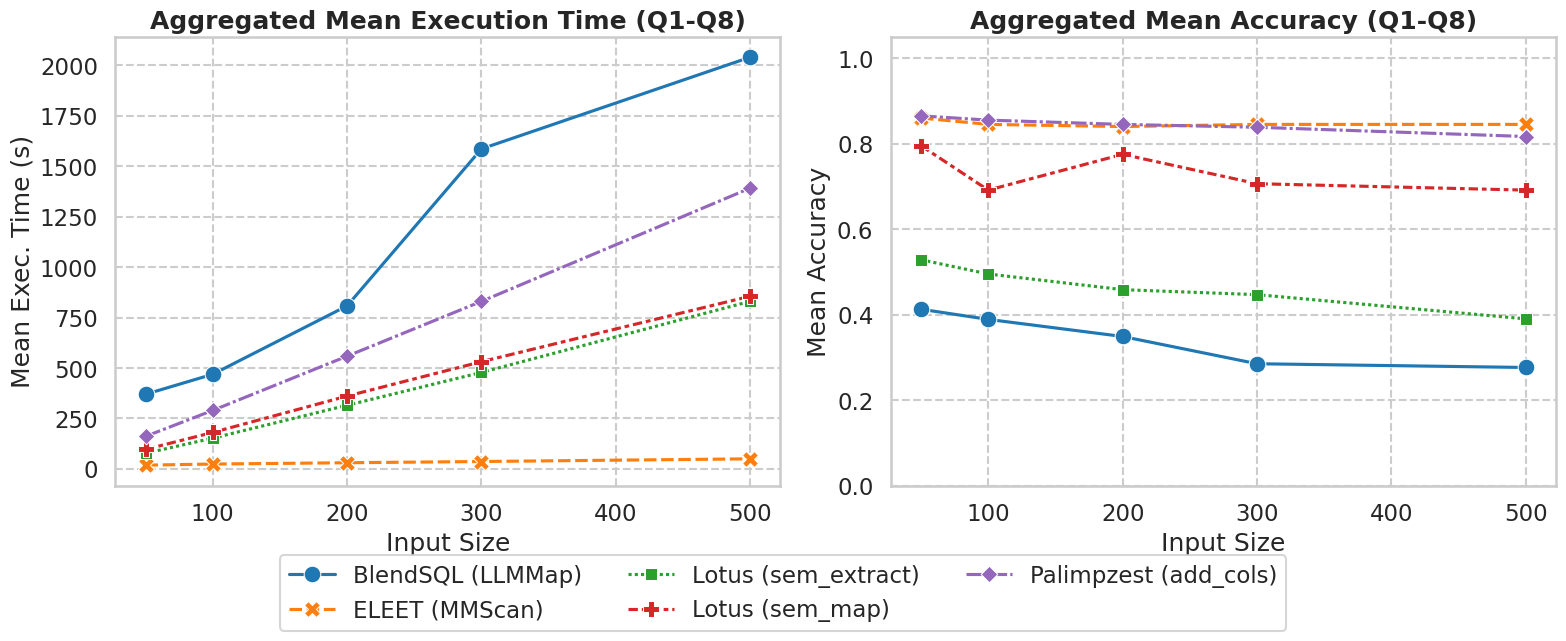

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Complete Data Assembly (Q1-Q8)
data = [
    # Q1
    ["Q1", "Lotus", "sem_map", 50, 15.92, 0.71], ["Q1", "Lotus", "sem_map", 100, 25.98, 0.64], ["Q1", "Lotus", "sem_map", 200, 61.93, 0.57], ["Q1", "Lotus", "sem_map", 300, 91.12, 0.52], ["Q1", "Lotus", "sem_map", 500, 132.00, 0.37],
    ["Q1", "Lotus", "sem_extract", 50, 4.96, 0.71], ["Q1", "Lotus", "sem_extract", 100, 8.27, 0.64], ["Q1", "Lotus", "sem_extract", 200, 17.49, 0.58], ["Q1", "Lotus", "sem_extract", 300, 23.95, 0.53], ["Q1", "Lotus", "sem_extract", 500, 38.70, 0.38],
    ["Q1", "Palimpzest", "add_cols", 50, 53.46, 0.67], ["Q1", "Palimpzest", "add_cols", 100, 95.07, 0.62], ["Q1", "Palimpzest", "add_cols", 200, 221.50, 0.56], ["Q1", "Palimpzest", "add_cols", 300, 275.17, 0.51], ["Q1", "Palimpzest", "add_cols", 500, 444.43, 0.37],
    ["Q1", "BlendSQL", "LLMMap", 50, 25.97, 0.60], ["Q1", "BlendSQL", "LLMMap", 100, 65.49, 0.53], ["Q1", "BlendSQL", "LLMMap", 200, 71.32, 0.47], ["Q1", "BlendSQL", "LLMMap", 300, 107.55, 0.45], ["Q1", "BlendSQL", "LLMMap", 500, 295.20, 0.30],
    # Q2
    ["Q2", "Lotus", "sem_map", 50, 5.44, 0.66], ["Q2", "Lotus", "sem_map", 100, 8.71, 0.68], ["Q2", "Lotus", "sem_map", 200, 13.02, 0.68], ["Q2", "Lotus", "sem_map", 300, 15.94, 0.69], ["Q2", "Lotus", "sem_map", 500, 31.60, 0.72],
    ["Q2", "BlendSQL", "LLMMap", 50, 10.97, 0.46], ["Q2", "BlendSQL", "LLMMap", 100, 18.01, 0.62], ["Q2", "BlendSQL", "LLMMap", 200, 270.40, 0.30], ["Q2", "BlendSQL", "LLMMap", 300, 40.17, 0.06], ["Q2", "BlendSQL", "LLMMap", 500, 281.75, 0.05],
    # Q3
    ["Q3", "Lotus", "sem_map", 50, 29.11, 0.88], ["Q3", "Lotus", "sem_map", 100, 85.20, 0.10], ["Q3", "Lotus", "sem_map", 200, 143.76, 0.88], ["Q3", "Lotus", "sem_map", 300, 198.36, 0.87], ["Q3", "Lotus", "sem_map", 500, 288.03, 0.87],
    ["Q3", "Lotus", "sem_extract", 50, 20.61, 0.17], ["Q3", "Lotus", "sem_extract", 100, 38.19, 0.10], ["Q3", "Lotus", "sem_extract", 200, 76.95, 0.06], ["Q3", "Lotus", "sem_extract", 300, 114.73, 0.05], ["Q3", "Lotus", "sem_extract", 500, 182.36, 0.04],
    ["Q3", "Palimpzest", "add_cols", 50, 54.77, 0.90], ["Q3", "Palimpzest", "add_cols", 100, 82.38, 0.90], ["Q3", "Palimpzest", "add_cols", 200, 174.79, 0.91], ["Q3", "Palimpzest", "add_cols", 300, 260.63, 0.89], ["Q3", "Palimpzest", "add_cols", 500, 422.58, 0.89],
    ["Q3", "BlendSQL", "LLMMap", 50, 39.70, 0.35], ["Q3", "BlendSQL", "LLMMap", 100, 59.69, 0.16], ["Q3", "BlendSQL", "LLMMap", 200, 236.87, 0.11], ["Q3", "BlendSQL", "LLMMap", 300, 106.85, 0.08], ["Q3", "BlendSQL", "LLMMap", 500, 308.09, 0.08],
    # Q4
    ["Q4", "Lotus", "sem_map", 50, 56.04, 0.87], ["Q4", "Lotus", "sem_map", 100, 105.14, 0.89], ["Q4", "Lotus", "sem_map", 200, 211.34, 0.88], ["Q4", "Lotus", "sem_map", 300, 320.37, 0.87], ["Q4", "Lotus", "sem_map", 500, 525.63, 0.86],
    ["Q4", "Lotus", "sem_extract", 50, 38.15, 0.85], ["Q4", "Lotus", "sem_extract", 100, 77.24, 0.90], ["Q4", "Lotus", "sem_extract", 200, 156.35, 0.88], ["Q4", "Lotus", "sem_extract", 300, 228.31, 0.88], ["Q4", "Lotus", "sem_extract", 500, 384.47, 0.88],
    ["Q4", "Palimpzest", "add_cols", 50, 67.35, 0.92], ["Q4", "Palimpzest", "add_cols", 100, 122.02, 0.95], ["Q4", "Palimpzest", "add_cols", 200, 239.00, 0.95], ["Q4", "Palimpzest", "add_cols", 300, 354.00, 0.96], ["Q4", "Palimpzest", "add_cols", 500, 591.39, 0.96],
    ["Q4", "BlendSQL", "LLMMap", 50, 163.92, 0.61], ["Q4", "BlendSQL", "LLMMap", 100, 376.88, 0.56], ["Q4", "BlendSQL", "LLMMap", 200, 446.07, 0.55], ["Q4", "BlendSQL", "LLMMap", 300, 559.78, 0.52], ["Q4", "BlendSQL", "LLMMap", 500, 913.36, 0.51],
    # Q5
    ["Q5", "Lotus", "sem_map", 50, 5.80, 0.57], ["Q5", "Lotus", "sem_map", 100, 9.54, 0.58], ["Q5", "Lotus", "sem_map", 200, 18.14, 0.56], ["Q5", "Lotus", "sem_map", 300, 28.81, 0.57], ["Q5", "Lotus", "sem_map", 500, 32.39, 0.57],
    ["Q5", "BlendSQL", "LLMMap", 50, 28.18, 0.53], ["Q5", "BlendSQL", "LLMMap", 100, 26.58, 0.50], ["Q5", "BlendSQL", "LLMMap", 200, 56.26, 0.55], ["Q5", "BlendSQL", "LLMMap", 300, 67.23, 0.49], ["Q5", "BlendSQL", "LLMMap", 500, 72.53, 0.50],
    # Q6
    ["Q6", "Lotus", "sem_map", 50, 19.18, 0.91], ["Q6", "Lotus", "sem_map", 100, 42.21, 0.90], ["Q6", "Lotus", "sem_map", 200, 88.74, 0.89], ["Q6", "Lotus", "sem_map", 300, 130.42, 0.89], ["Q6", "Lotus", "sem_map", 500, 212.42, 0.89],
    ["Q6", "Lotus", "sem_extract", 50, 23.72, 0.17], ["Q6", "Lotus", "sem_extract", 100, 45.30, 0.13], ["Q6", "Lotus", "sem_extract", 200, 115.33, 0.08], ["Q6", "Lotus", "sem_extract", 300, 162.15, 0.08], ["Q6", "Lotus", "sem_extract", 500, 244.53, 0.07],
    ["Q6", "Palimpzest", "add_cols", 50, 61.85, 0.91], ["Q6", "Palimpzest", "add_cols", 100, 107.19, 0.88], ["Q6", "Palimpzest", "add_cols", 200, 242.33, 0.88], ["Q6", "Palimpzest", "add_cols", 300, 311.36, 0.89], ["Q6", "Palimpzest", "add_cols", 500, 502.61, 0.90],
    ["Q6", "BlendSQL", "LLMMap", 50, 120.44, 0.11], ["Q6", "BlendSQL", "LLMMap", 100, 242.98, 0.12], ["Q6", "BlendSQL", "LLMMap", 200, 453.40, 0.11], ["Q6", "BlendSQL", "LLMMap", 300, 460.19, 0.12], ["Q6", "BlendSQL", "LLMMap", 500, 797.71, 0.12],
    # Q7
    ["Q7", "Lotus", "sem_map", 50, 552.77, 0.88], ["Q7", "Lotus", "sem_map", 100, 993.76, 0.87], ["Q7", "Lotus", "sem_map", 200, 2000.09, 0.87], ["Q7", "Lotus", "sem_map", 300, 2944.63, 0.68], ["Q7", "Lotus", "sem_map", 500, 4774.96, 0.68],
    ["Q7", "Lotus", "sem_extract", 50, 325.53, 0.95], ["Q7", "Lotus", "sem_extract", 100, 635.13, 0.94], ["Q7", "Lotus", "sem_extract", 200, 1269.23, 0.94], ["Q7", "Lotus", "sem_extract", 300, 1893.17, 0.94], ["Q7", "Lotus", "sem_extract", 500, 3193.82, 0.76],
    ["Q7", "Palimpzest", "add_cols", 50, 560.28, 0.96], ["Q7", "Palimpzest", "add_cols", 100, 1004.26, 0.95], ["Q7", "Palimpzest", "add_cols", 200, 1827.41, 0.95], ["Q7", "Palimpzest", "add_cols", 300, 2790.05, 0.95], ["Q7", "Palimpzest", "add_cols", 500, 4805.79, 0.95],
    ["Q7", "BlendSQL", "LLMMap", 50, 1823.89, 0.46], ["Q7", "BlendSQL", "LLMMap", 100, 2427.90, 0.45], ["Q7", "BlendSQL", "LLMMap", 200, 3046.68, 0.58], ["Q7", "BlendSQL", "LLMMap", 300, 7305.57, 0.46], ["Q7", "BlendSQL", "LLMMap", 500, 9062.82, 0.50],
    ["Q7", "ELEET", "MMScan", 50, 20.60, 0.83], ["Q7", "ELEET", "MMScan", 100, 26.45, 0.82], ["Q7", "ELEET", "MMScan", 200, 37.19, 0.81], ["Q7", "ELEET", "MMScan", 300, 47.33, 0.82], ["Q7", "ELEET", "MMScan", 500, 66.82, 0.82],
    # Q8
    ["Q8", "Lotus", "sem_map", 50, 89.09, 0.88], ["Q8", "Lotus", "sem_map", 100, 175.56, 0.87], ["Q8", "Lotus", "sem_map", 200, 351.76, 0.87], ["Q8", "Lotus", "sem_map", 300, 522.03, 0.56], ["Q8", "Lotus", "sem_map", 500, 851.00, 0.57],
    ["Q8", "Lotus", "sem_extract", 50, 51.76, 0.32], ["Q8", "Lotus", "sem_extract", 100, 111.15, 0.26], ["Q8", "Lotus", "sem_extract", 200, 257.47, 0.21], ["Q8", "Lotus", "sem_extract", 300, 447.67, 0.20], ["Q8", "Lotus", "sem_extract", 500, 940.20, 0.21],
    ["Q8", "Palimpzest", "add_cols", 50, 170.22, 0.83], ["Q8", "Palimpzest", "add_cols", 100, 329.60, 0.83], ["Q8", "Palimpzest", "add_cols", 200, 648.29, 0.82], ["Q8", "Palimpzest", "add_cols", 300, 991.81, 0.83], ["Q8", "Palimpzest", "add_cols", 500, 1584.21, 0.83],
    ["Q8", "BlendSQL", "LLMMap", 50, 747.19, 0.18], ["Q8", "BlendSQL", "LLMMap", 100, 535.47, 0.17], ["Q8", "BlendSQL", "LLMMap", 200, 1884.79, 0.12], ["Q8", "BlendSQL", "LLMMap", 300, 4043.17, 0.1], ["Q8", "BlendSQL", "LLMMap", 500, 4594.27, 0.15],
    ["Q8", "ELEET", "MMScan", 50, 16.98, 0.89], ["Q8", "ELEET", "MMScan", 100, 22.01, 0.87], ["Q8", "ELEET", "MMScan", 200, 24.22, 0.87], ["Q8", "ELEET", "MMScan", 300, 26.30, 0.87], ["Q8", "ELEET", "MMScan", 500, 33.21, 0.87],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# 2. Aggregate across all Queries
# We group by Label and InputSize and take the mean of Time and Accuracy
agg_df = df.groupby(["Label", "InputSize"])[["Time", "Accuracy"]].mean().reset_index()

# 3. Plotting the Aggregated Results
sns.set_context("talk")
sns.set_style("whitegrid", {'grid.linestyle': '--'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Average Execution Time
sns.lineplot(data=agg_df, x="InputSize", y="Time", hue="Label", style="Label", 
             markers=True, markersize=12, ax=ax1)
ax1.set_title("Aggregated Mean Execution Time (Q1-Q8)", fontweight='bold')
ax1.set_ylabel("Mean Exec. Time (s)")
ax1.set_xlabel("Input Size")
ax1.get_legend().remove()

# Subplot 2: Average Accuracy
sns.lineplot(data=agg_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
             markers=True, markersize=12, ax=ax2)
ax2.set_title("Aggregated Mean Accuracy (Q1-Q8)", fontweight='bold')
ax2.set_ylabel("Mean Accuracy")
ax2.set_xlabel("Input Size")
ax2.set_ylim(0, 1.05)

# Place legend in the middle or bottom
handles, labels = ax2.get_legend_handles_labels()
ax2.legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=True)

plt.tight_layout()
plt.show()

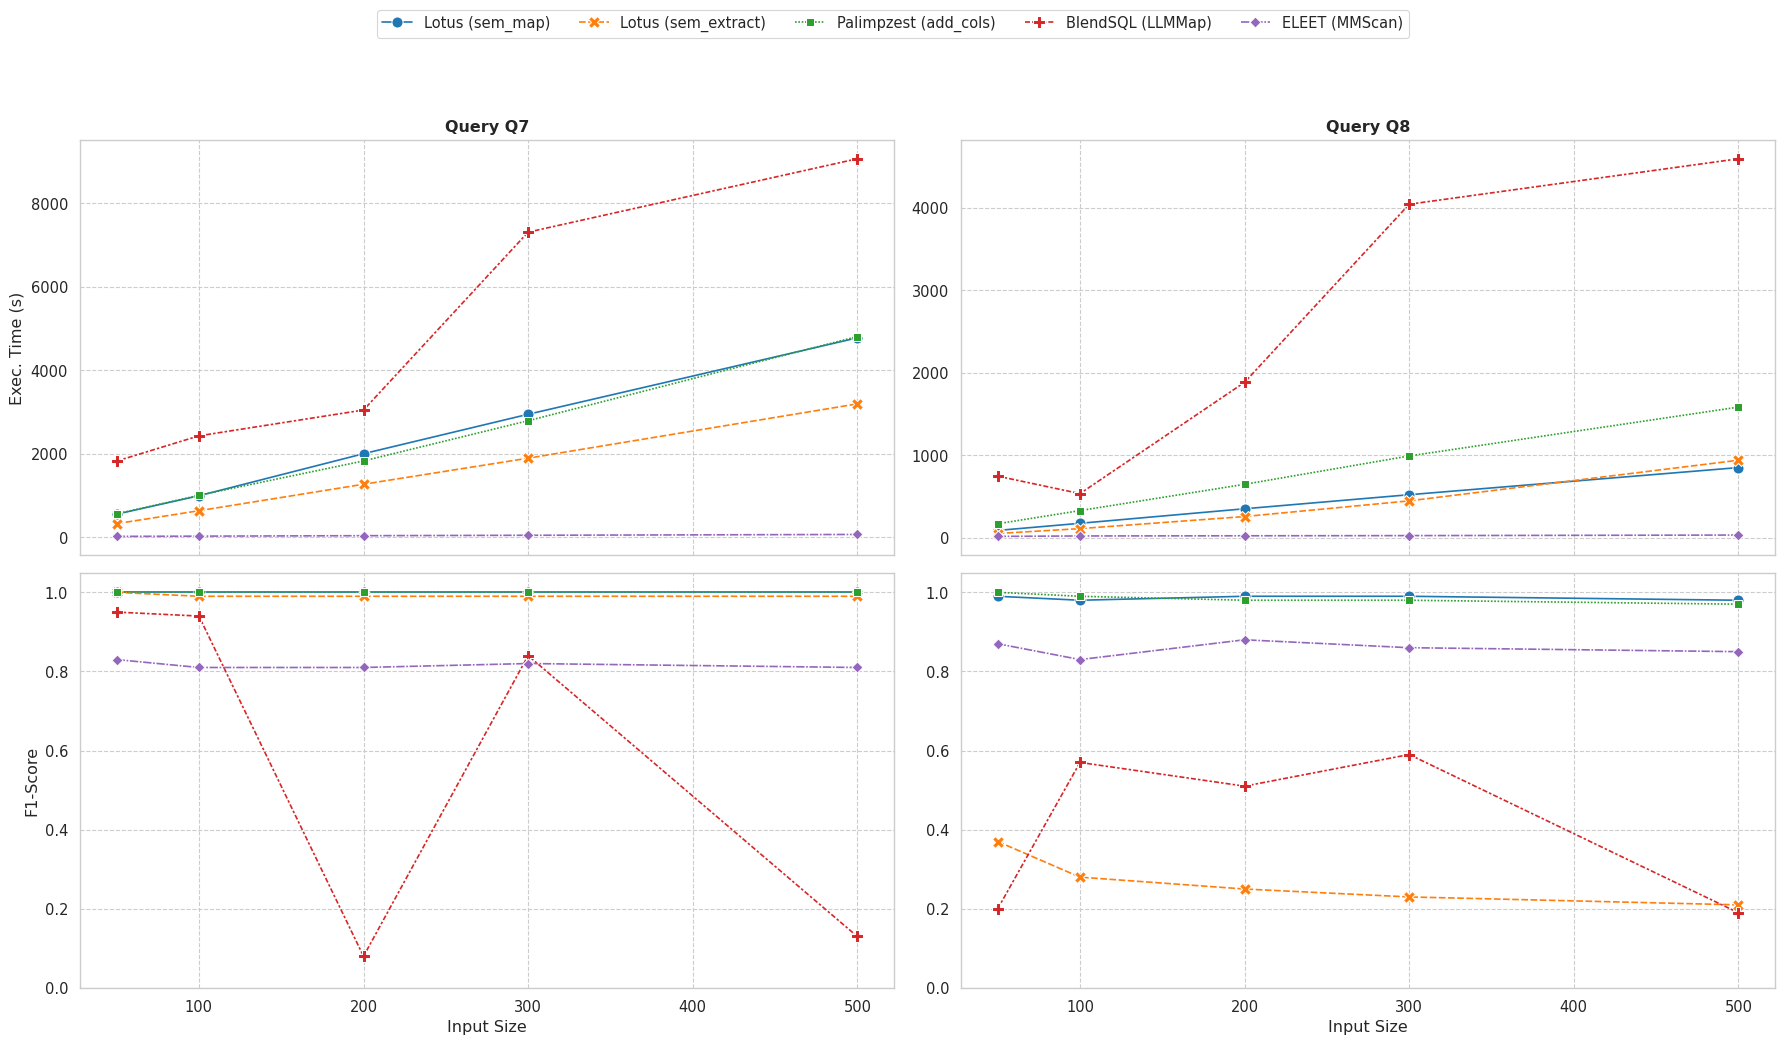

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data already defined above
df = pd.DataFrame(
    data,
    columns=["Query", "System", "Operator", "InputSize", "Time", "F1"]
)
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# Plot style
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

queries = ["Q7", "Q8"]

# 2 rows (Time, F1) × 2 columns (Q7, Q8)
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex="col")

for col, q in enumerate(queries):
    q_df = df[df["Query"] == q]

    # --- Execution Time ---
    ax_time = axes[0, col]
    sns.lineplot(
        data=q_df,
        x="InputSize",
        y="Time",
        hue="Label",
        style="Label",
        markers=True,
        markersize=8,
        ax=ax_time,
        legend=(col == 1)  # show legend only once
    )
    ax_time.set_title(f"Query {q}", fontweight="bold")
    ax_time.set_ylabel("Exec. Time (s)" if col == 0 else "")
    ax_time.set_xlabel("")

    # --- F1 Score ---
    ax_f1 = axes[1, col]
    sns.lineplot(
        data=q_df,
        x="InputSize",
        y="F1",
        hue="Label",
        style="Label",
        markers=True,
        markersize=8,
        ax=ax_f1,
        legend=False
    )
    ax_f1.set_ylim(0, 1.05)
    ax_f1.set_ylabel("F1-Score" if col == 0 else "")
    ax_f1.set_xlabel("Input Size")

# Extract legend handles
handles, labels = axes[0, 1].get_legend_handles_labels()
axes[0, 1].legend().remove()

# Global legend
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=5,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


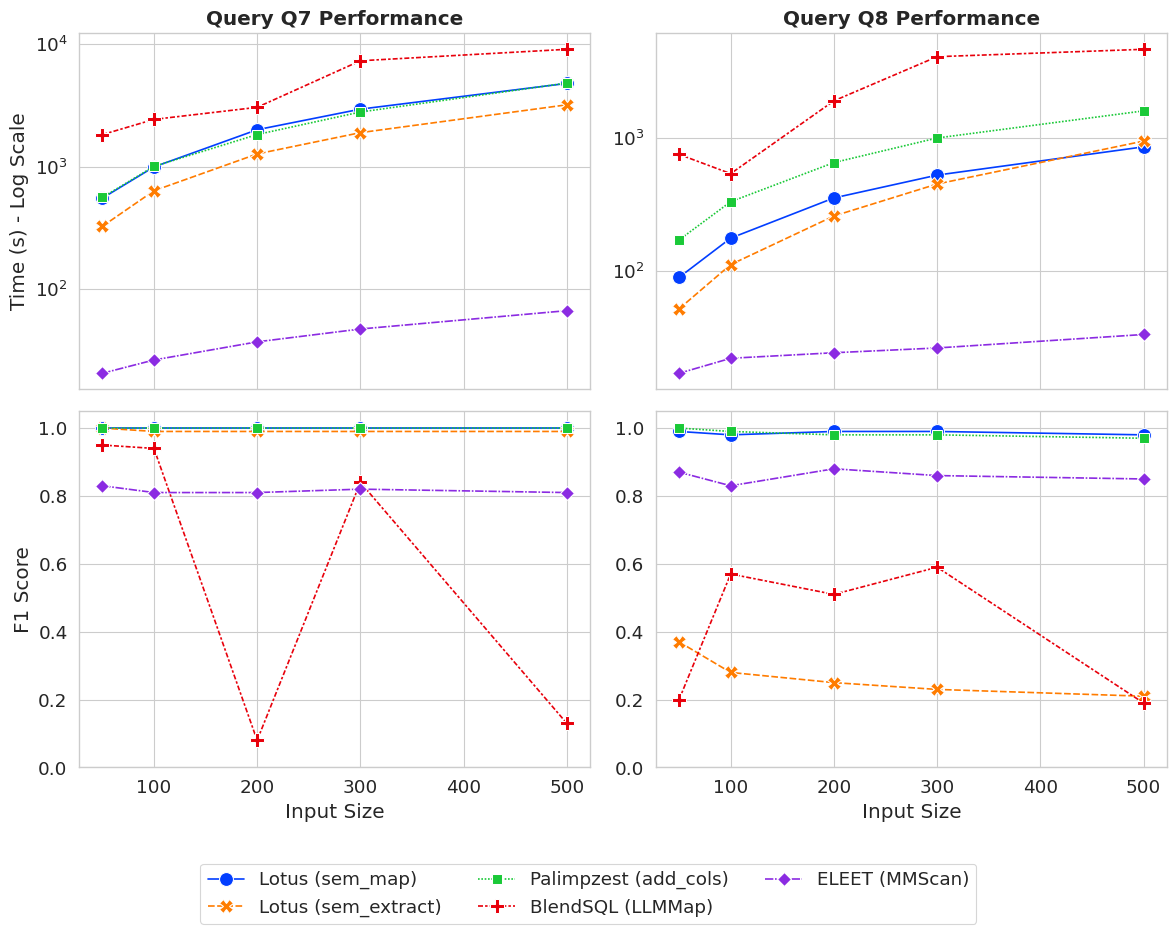

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare the data
# Format: [Query, System, Operator, Size, Time, F1, Accuracy]
data = [
    # Q7 Data
    ["Q7", "Lotus", "sem_map", 50, 552.77, 1.00, 0.88], ["Q7", "Lotus", "sem_map", 100, 993.76, 1.00, 0.87],
    ["Q7", "Lotus", "sem_map", 200, 2000.09, 1.00, 0.87], ["Q7", "Lotus", "sem_map", 300, 2944.63, 1.00, 0.68],
    ["Q7", "Lotus", "sem_map", 500, 4774.96, 1.00, 0.68],
    ["Q7", "Lotus", "sem_extract", 50, 325.53, 1.00, 0.95], ["Q7", "Lotus", "sem_extract", 100, 635.13, 0.99, 0.94],
    ["Q7", "Lotus", "sem_extract", 200, 1269.23, 0.99, 0.94], ["Q7", "Lotus", "sem_extract", 300, 1893.17, 0.99, 0.94],
    ["Q7", "Lotus", "sem_extract", 500, 3193.82, 0.99, 0.76],
    ["Q7", "Palimpzest", "add_cols", 50, 560.28, 1.00, 0.96], ["Q7", "Palimpzest", "add_cols", 100, 1004.26, 1.00, 0.95],
    ["Q7", "Palimpzest", "add_cols", 200, 1827.41, 1.00, 0.95], ["Q7", "Palimpzest", "add_cols", 300, 2790.05, 1.00, 0.95],
    ["Q7", "Palimpzest", "add_cols", 500, 4805.79, 1.00, 0.95],
    ["Q7", "BlendSQL", "LLMMap", 50, 1823.89, 0.95, 0.46], ["Q7", "BlendSQL", "LLMMap", 100, 2427.90, 0.94, 0.45],
    ["Q7", "BlendSQL", "LLMMap", 200, 3046.68, 0.08, 0.58], ["Q7", "BlendSQL", "LLMMap", 300, 7305.57, 0.84, 0.46],
    ["Q7", "BlendSQL", "LLMMap", 500, 9062.82, 0.13, 0.50],
    ["Q7", "ELEET", "MMScan", 50, 20.60, 0.83, 0.83], ["Q7", "ELEET", "MMScan", 100, 26.45, 0.81, 0.82],
    ["Q7", "ELEET", "MMScan", 200, 37.19, 0.81, 0.81], ["Q7", "ELEET", "MMScan", 300, 47.33, 0.82, 0.82],
    ["Q7", "ELEET", "MMScan", 500, 66.82, 0.81, 0.82],

    # Q8 Data
    ["Q8", "Lotus", "sem_map", 50, 89.09, 0.99, 0.88], ["Q8", "Lotus", "sem_map", 100, 175.56, 0.98, 0.87],
    ["Q8", "Lotus", "sem_map", 200, 351.76, 0.99, 0.87], ["Q8", "Lotus", "sem_map", 300, 522.03, 0.99, 0.56],
    ["Q8", "Lotus", "sem_map", 500, 851.00, 0.98, 0.57],
    ["Q8", "Lotus", "sem_extract", 50, 51.76, 0.37, 0.32], ["Q8", "Lotus", "sem_extract", 100, 111.15, 0.28, 0.26],
    ["Q8", "Lotus", "sem_extract", 200, 257.47, 0.25, 0.21], ["Q8", "Lotus", "sem_extract", 300, 447.67, 0.23, 0.20],
    ["Q8", "Lotus", "sem_extract", 500, 940.20, 0.21, 0.21],
    ["Q8", "Palimpzest", "add_cols", 50, 170.22, 1.00, 0.83], ["Q8", "Palimpzest", "add_cols", 100, 329.60, 0.99, 0.83],
    ["Q8", "Palimpzest", "add_cols", 200, 648.29, 0.98, 0.82], ["Q8", "Palimpzest", "add_cols", 300, 991.81, 0.98, 0.83],
    ["Q8", "Palimpzest", "add_cols", 500, 1584.21, 0.97, 0.83],
    ["Q8", "BlendSQL", "LLMMap", 50, 747.19, 0.20, 0.18], ["Q8", "BlendSQL", "LLMMap", 100, 535.47, 0.57, 0.17],
    ["Q8", "BlendSQL", "LLMMap", 200, 1884.79, 0.51, 0.12], ["Q8", "BlendSQL", "LLMMap", 300, 4043.17, 0.59, 0.10],
    ["Q8", "BlendSQL", "LLMMap", 500, 4594.27, 0.19, 0.15],
    ["Q8", "ELEET", "MMScan", 50, 16.98, 0.87, 0.89], ["Q8", "ELEET", "MMScan", 100, 22.01, 0.83, 0.87],
    ["Q8", "ELEET", "MMScan", 200, 24.22, 0.88, 0.87], ["Q8", "ELEET", "MMScan", 300, 26.30, 0.86, 0.87],
    ["Q8", "ELEET", "MMScan", 500, 33.21, 0.85, 0.87],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "F1", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# 2. Plotting
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)

queries = ["Q7", "Q8"]
palette = sns.color_palette("bright", n_colors=df["Label"].nunique())

for i, q in enumerate(queries):
    q_df = df[df["Query"] == q]
    
    # ROW 0: Time (LOG SCALE)
    lp = sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", style="Label", 
                 markers=True, markersize=10, ax=axes[0, i], palette=palette, legend=(i==0))
    axes[0, i].set_yscale('log')
    axes[0, i].set_title(f"Query {q} Performance", fontweight='bold')
    axes[0, i].set_ylabel("Time (s) - Log Scale" if i==0 else "")

    # ROW 1: Accuracy
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
                 markers=True, markersize=10, ax=axes[1, i], palette=palette, legend=False)
    axes[1, i].set_ylim(0, 1.05)
    axes[1, i].set_ylabel("Accuracy" if i==0 else "")
    axes[1, i].set_xlabel("Input Size")

    # ROW 2: F1 Score
    sns.lineplot(
        data=q_df,
        x="InputSize",
        y="F1",
        hue="Label",
        style="Label",
        markers=True,
        markersize=10,
        ax=axes[2, i],
        palette=palette,
        legend=False
    )
    axes[2, i].set_ylim(0, 1.05)
    axes[2, i].set_ylabel("F1 Score" if i == 0 else "")
    axes[2, i].set_xlabel("Input Size")


# Handle Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [4]:
# THE FINAL CODE

IndexError: index 3 is out of bounds for axis 1 with size 3

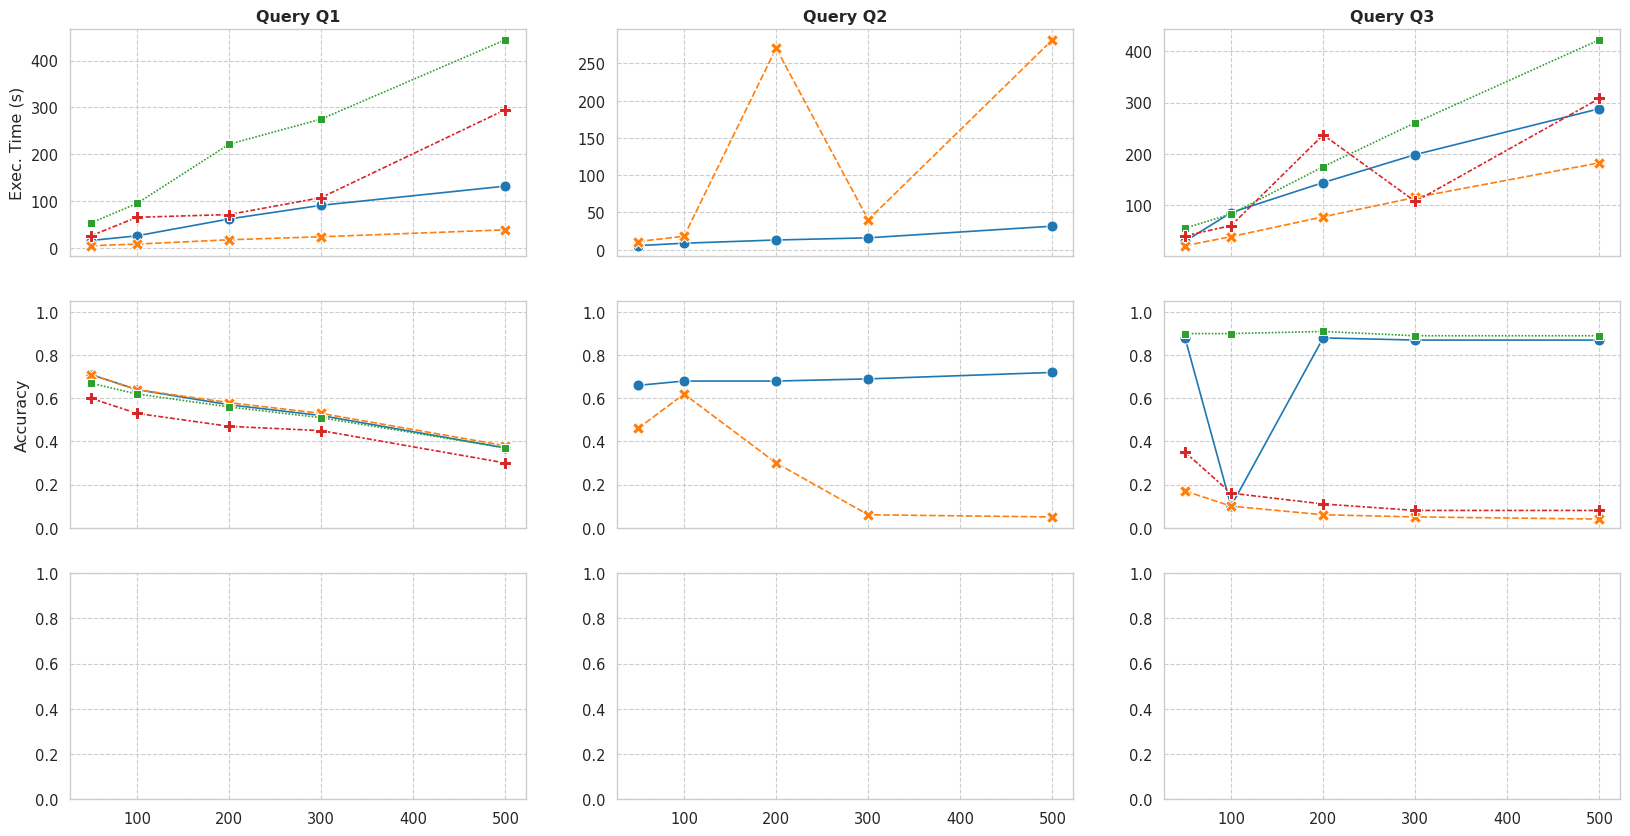

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare the data from LaTeX tables (excluding Q7, Q8)
data = [
    # Query, System, Op, Size, Time, Acc
    # Q1
    ["Q1", "Lotus", "sem_map", 50, 15.92, 0.71], ["Q1", "Lotus", "sem_map", 100, 25.98, 0.64], ["Q1", "Lotus", "sem_map", 200, 61.93, 0.57], ["Q1", "Lotus", "sem_map", 300, 91.12, 0.52], ["Q1", "Lotus", "sem_map", 500, 132.00, 0.37],
    ["Q1", "Lotus", "sem_extract", 50, 4.96, 0.71], ["Q1", "Lotus", "sem_extract", 100, 8.27, 0.64], ["Q1", "Lotus", "sem_extract", 200, 17.49, 0.58], ["Q1", "Lotus", "sem_extract", 300, 23.95, 0.53], ["Q1", "Lotus", "sem_extract", 500, 38.70, 0.38],
    ["Q1", "Palimpzest", "add_cols", 50, 53.46, 0.67], ["Q1", "Palimpzest", "add_cols", 100, 95.07, 0.62], ["Q1", "Palimpzest", "add_cols", 200, 221.50, 0.56], ["Q1", "Palimpzest", "add_cols", 300, 275.17, 0.51], ["Q1", "Palimpzest", "add_cols", 500, 444.43, 0.37],
    ["Q1", "BlendSQL", "LLMMap", 50, 25.97, 0.60], ["Q1", "BlendSQL", "LLMMap", 100, 65.49, 0.53], ["Q1", "BlendSQL", "LLMMap", 200, 71.32, 0.47], ["Q1", "BlendSQL", "LLMMap", 300, 107.55, 0.45], ["Q1", "BlendSQL", "LLMMap", 500, 295.20, 0.30],
    # Q2
    ["Q2", "Lotus", "sem_map", 50, 5.44, 0.66], ["Q2", "Lotus", "sem_map", 100, 8.71, 0.68], ["Q2", "Lotus", "sem_map", 200, 13.02, 0.68], ["Q2", "Lotus", "sem_map", 300, 15.94, 0.69], ["Q2", "Lotus", "sem_map", 500, 31.60, 0.72],
    ["Q2", "BlendSQL", "LLMMap", 50, 10.97, 0.46], ["Q2", "BlendSQL", "LLMMap", 100, 18.01, 0.62], ["Q2", "BlendSQL", "LLMMap", 200, 270.40, 0.30], ["Q2", "BlendSQL", "LLMMap", 300, 40.17, 0.06], ["Q2", "BlendSQL", "LLMMap", 500, 281.75, 0.05],
    # Q3
    ["Q3", "Lotus", "sem_map", 50, 29.11, 0.88], ["Q3", "Lotus", "sem_map", 100, 85.20, 0.10], ["Q3", "Lotus", "sem_map", 200, 143.76, 0.88], ["Q3", "Lotus", "sem_map", 300, 198.36, 0.87], ["Q3", "Lotus", "sem_map", 500, 288.03, 0.87],
    ["Q3", "Lotus", "sem_extract", 50, 20.61, 0.17], ["Q3", "Lotus", "sem_extract", 100, 38.19, 0.10], ["Q3", "Lotus", "sem_extract", 200, 76.95, 0.06], ["Q3", "Lotus", "sem_extract", 300, 114.73, 0.05], ["Q3", "Lotus", "sem_extract", 500, 182.36, 0.04],
    ["Q3", "Palimpzest", "add_cols", 50, 54.77, 0.90], ["Q3", "Palimpzest", "add_cols", 100, 82.38, 0.90], ["Q3", "Palimpzest", "add_cols", 200, 174.79, 0.91], ["Q3", "Palimpzest", "add_cols", 300, 260.63, 0.89], ["Q3", "Palimpzest", "add_cols", 500, 422.58, 0.89],
    ["Q3", "BlendSQL", "LLMMap", 50, 39.70, 0.35], ["Q3", "BlendSQL", "LLMMap", 100, 59.69, 0.16], ["Q3", "BlendSQL", "LLMMap", 200, 236.87, 0.11], ["Q3", "BlendSQL", "LLMMap", 300, 106.85, 0.08], ["Q3", "BlendSQL", "LLMMap", 500, 308.09, 0.08],
    # Q4
    ["Q4", "Lotus", "sem_map", 50, 56.04, 0.87], ["Q4", "Lotus", "sem_map", 100, 105.14, 0.89], ["Q4", "Lotus", "sem_map", 200, 211.34, 0.88], ["Q4", "Lotus", "sem_map", 300, 320.37, 0.87], ["Q4", "Lotus", "sem_map", 500, 525.63, 0.86],
    ["Q4", "Lotus", "sem_extract", 50, 38.15, 0.85], ["Q4", "Lotus", "sem_extract", 100, 77.24, 0.90], ["Q4", "Lotus", "sem_extract", 200, 156.35, 0.88], ["Q4", "Lotus", "sem_extract", 300, 228.31, 0.88], ["Q4", "Lotus", "sem_extract", 500, 384.47, 0.88],
    ["Q4", "Palimpzest", "add_cols", 50, 67.35, 0.92], ["Q4", "Palimpzest", "add_cols", 100, 122.02, 0.95], ["Q4", "Palimpzest", "add_cols", 200, 239.00, 0.95], ["Q4", "Palimpzest", "add_cols", 300, 354.00, 0.96], ["Q4", "Palimpzest", "add_cols", 500, 591.39, 0.96],
    ["Q4", "BlendSQL", "LLMMap", 50, 163.92, 0.61], ["Q4", "BlendSQL", "LLMMap", 100, 376.88, 0.56], ["Q4", "BlendSQL", "LLMMap", 200, 446.07, 0.55], ["Q4", "BlendSQL", "LLMMap", 300, 559.78, 0.52], ["Q4", "BlendSQL", "LLMMap", 500, 913.36, 0.51],
    # Q5
    ["Q5", "Lotus", "sem_map", 50, 5.80, 0.57], ["Q5", "Lotus", "sem_map", 100, 9.54, 0.58], ["Q5", "Lotus", "sem_map", 200, 18.14, 0.56], ["Q5", "Lotus", "sem_map", 300, 28.81, 0.57], ["Q5", "Lotus", "sem_map", 500, 32.39, 0.57],
    ["Q5", "BlendSQL", "LLMMap", 50, 28.18, 0.53], ["Q5", "BlendSQL", "LLMMap", 100, 26.58, 0.50], ["Q5", "BlendSQL", "LLMMap", 200, 56.26, 0.55], ["Q5", "BlendSQL", "LLMMap", 300, 67.23, 0.49], ["Q5", "BlendSQL", "LLMMap", 500, 72.53, 0.50],
    # Q6
    ["Q6", "Lotus", "sem_map", 50, 19.18, 0.91], ["Q6", "Lotus", "sem_map", 100, 42.21, 0.90], ["Q6", "Lotus", "sem_map", 200, 88.74, 0.89], ["Q6", "Lotus", "sem_map", 300, 130.42, 0.89], ["Q6", "Lotus", "sem_map", 500, 212.42, 0.89],
    ["Q6", "Lotus", "sem_extract", 50, 23.72, 0.17], ["Q6", "Lotus", "sem_extract", 100, 45.30, 0.13], ["Q6", "Lotus", "sem_extract", 200, 115.33, 0.08], ["Q6", "Lotus", "sem_extract", 300, 162.15, 0.08], ["Q6", "Lotus", "sem_extract", 500, 244.53, 0.07],
    ["Q6", "Palimpzest", "add_cols", 50, 61.85, 0.91], ["Q6", "Palimpzest", "add_cols", 100, 107.19, 0.88], ["Q6", "Palimpzest", "add_cols", 200, 242.33, 0.88], ["Q6", "Palimpzest", "add_cols", 300, 311.36, 0.89], ["Q6", "Palimpzest", "add_cols", 500, 502.61, 0.90],
    ["Q6", "BlendSQL", "LLMMap", 50, 120.44, 0.11], ["Q6", "BlendSQL", "LLMMap", 100, 242.98, 0.12], ["Q6", "BlendSQL", "LLMMap", 200, 453.40, 0.11], ["Q6", "BlendSQL", "LLMMap", 300, 460.19, 0.12], ["Q6", "BlendSQL", "LLMMap", 500, 797.71, 0.12],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# 2. Set Plotting Style
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

# Plot 6 queries in a 3-row grid (Row 0&1: Time, Row 2&3: Acc)
fig, axes = plt.subplots(3, , figsize=(20, 10), sharex=True)

queries = ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6"]
y_labels = ["Exec. Time (s)", "Accuracy"]

for idx, q in enumerate(queries):
    col = idx % 4
    row_offset = 0 if idx < 4 else 2  # 0 for Q1-Q4, 2 for Q5-Q6
    
    q_df = df[df["Query"] == q]
    
    # Execution Time Plot (Row 0 for Q1-Q4, Row 2 for Q5-Q6)
    ax_time = axes[0 if idx < 4 else 1, col]
    sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", 
                 style="Label", markers=True, markersize=8, ax=ax_time, legend=(idx == 3))
    ax_time.set_title(f"Query {q}", fontweight='bold')
    ax_time.set_ylabel(y_labels[0] if col == 0 else "")
    ax_time.set_xlabel("")
    
    # Accuracy Plot (Row 1 for Q1-Q4, Row 3 for Q5-Q6)
    ax_acc = axes[1 if idx < 4 else 2, col]
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", 
                 style="Label", markers=True, markersize=8, ax=ax_acc, legend=False)
    ax_acc.set_ylim(0, 1.05)
    ax_acc.set_ylabel(y_labels[1] if col == 0 else "")
    ax_acc.set_xlabel("Input Size" if row_offset == 2 else "")

# Adjust legend
handles, labels = axes[0, 3].get_legend_handles_labels()
axes[0, 3].legend().remove()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=True, fontsize='medium')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


Generating individual plots for Q1-Q6...


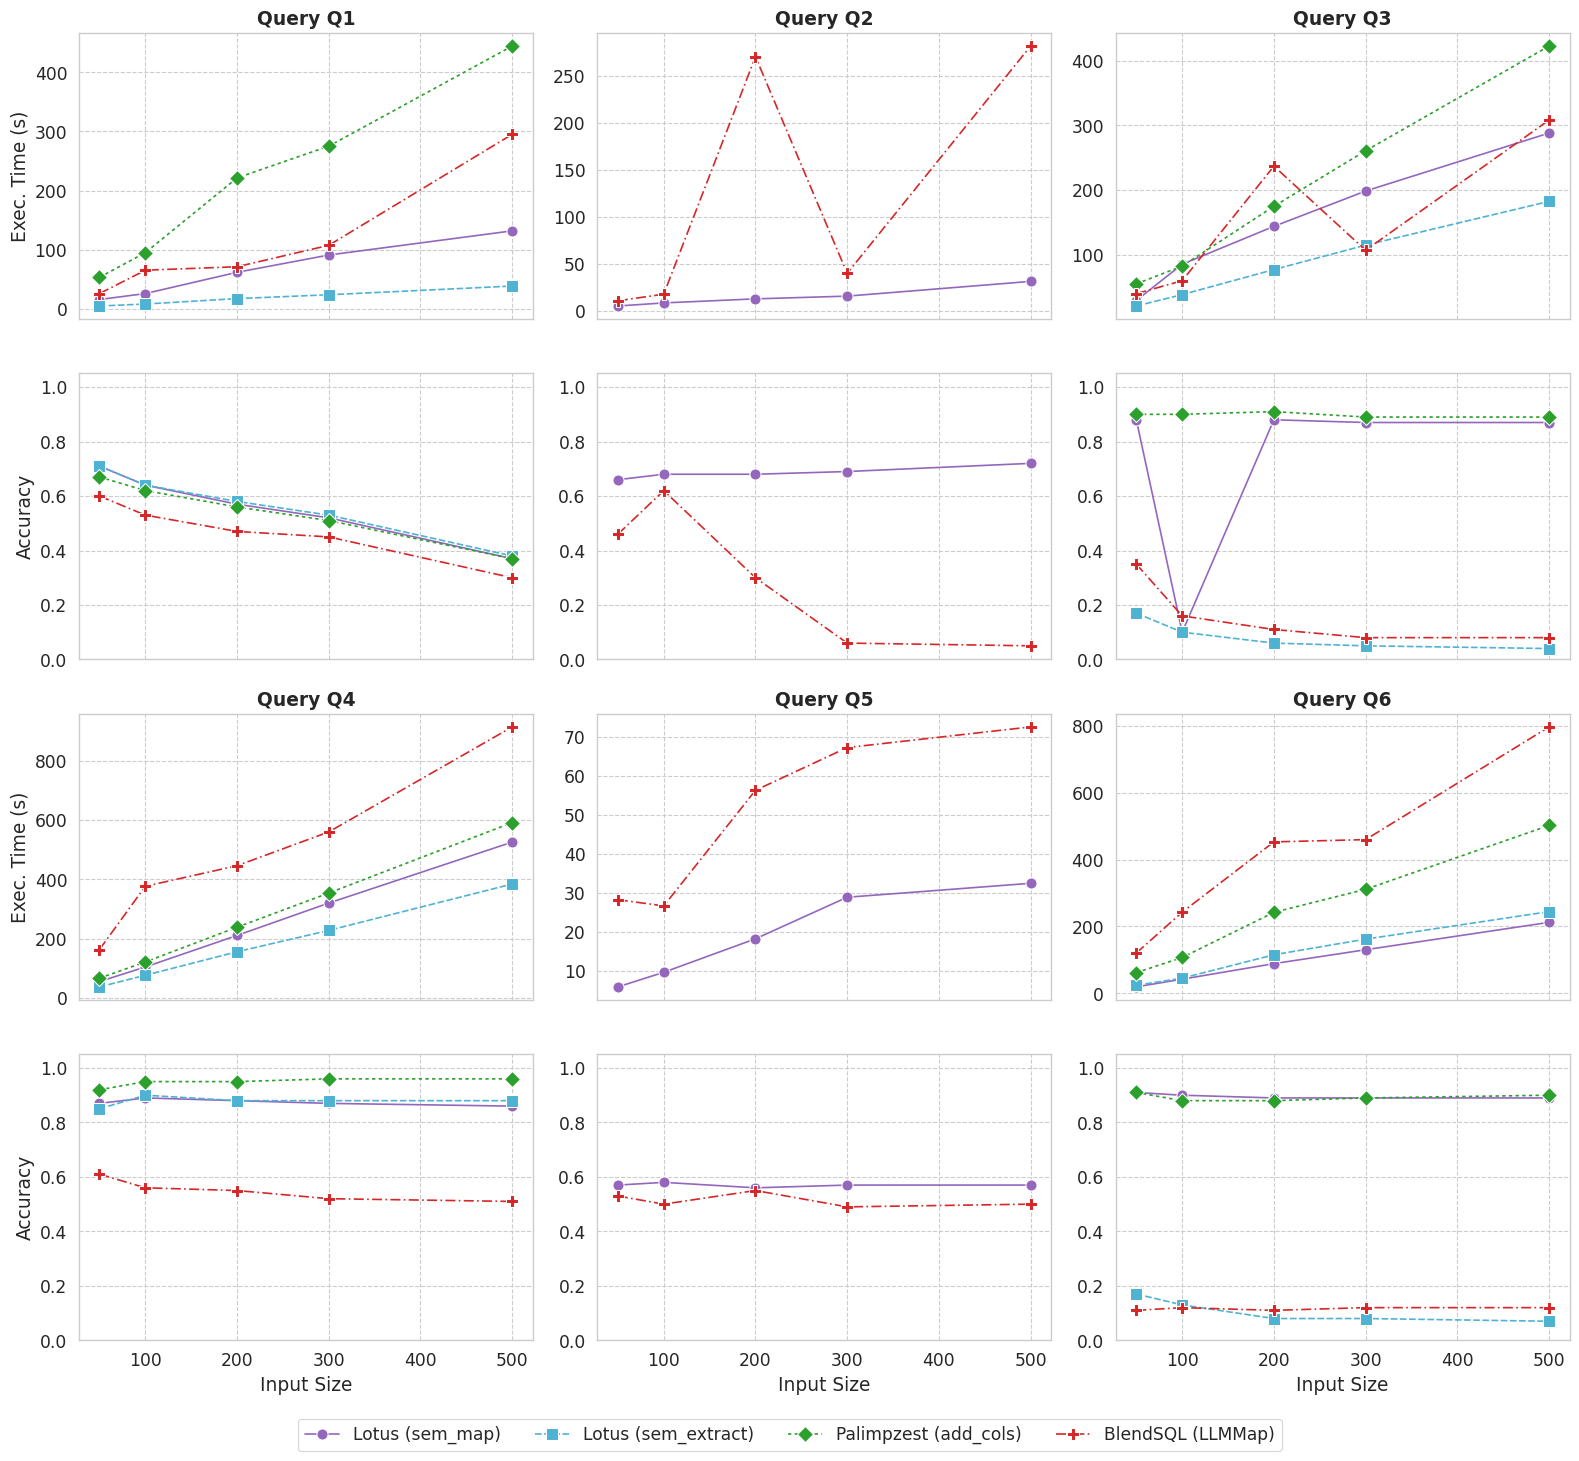

Generating aggregated plots for Q1-Q6...


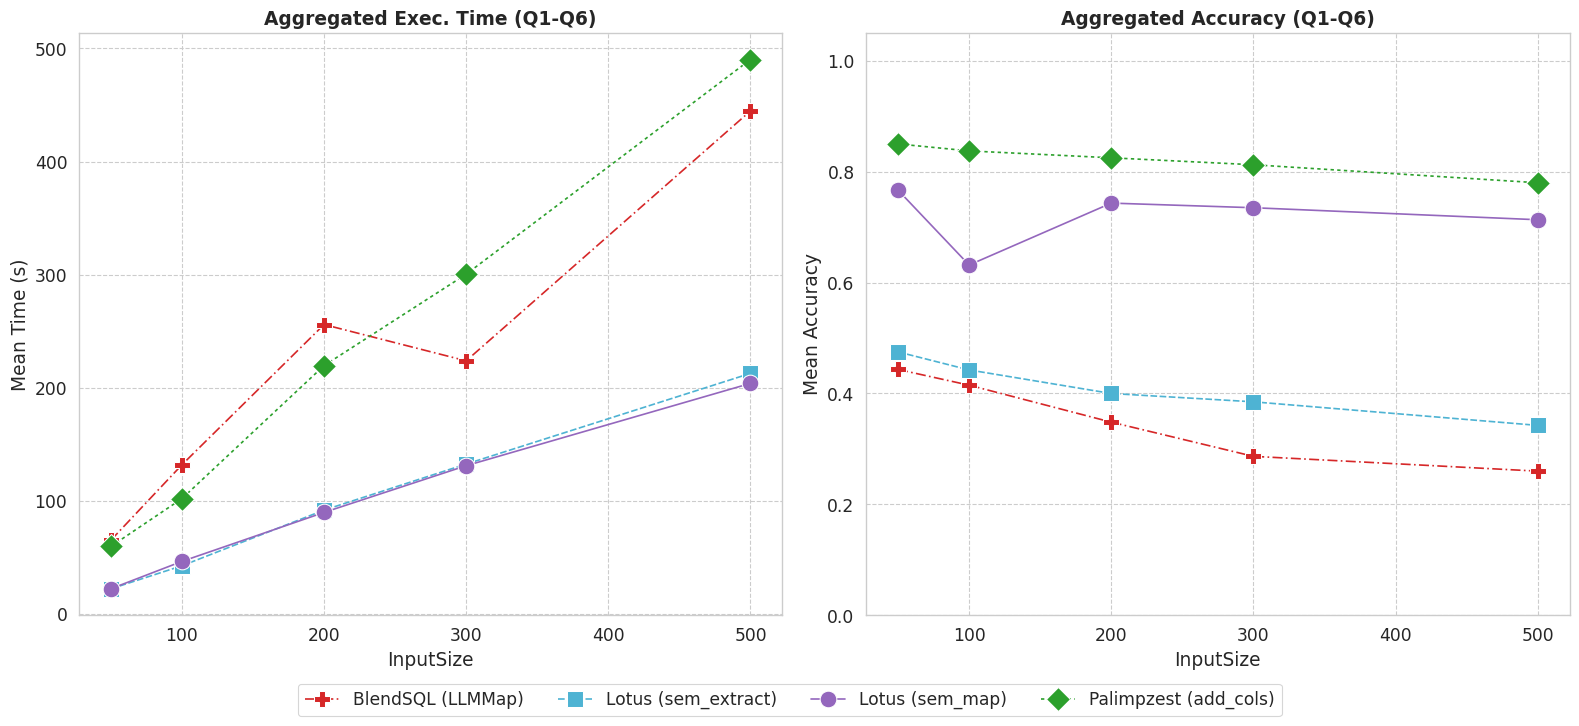

Generating individual plots for Q7-Q8...


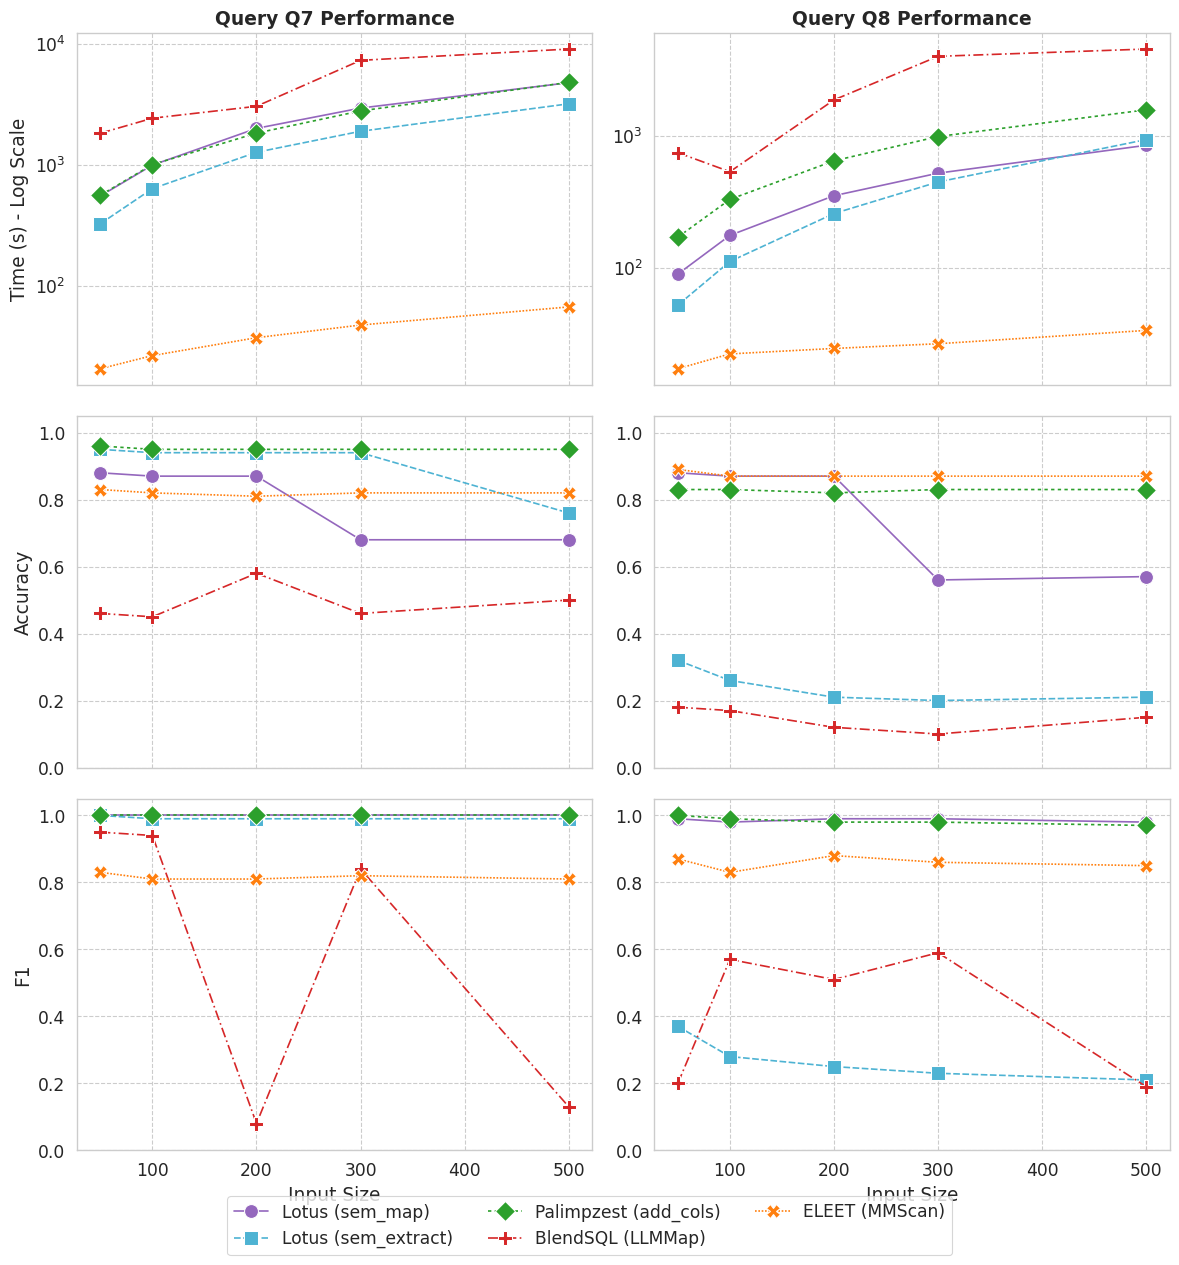

Generating aggregated plots for Q7-Q8...


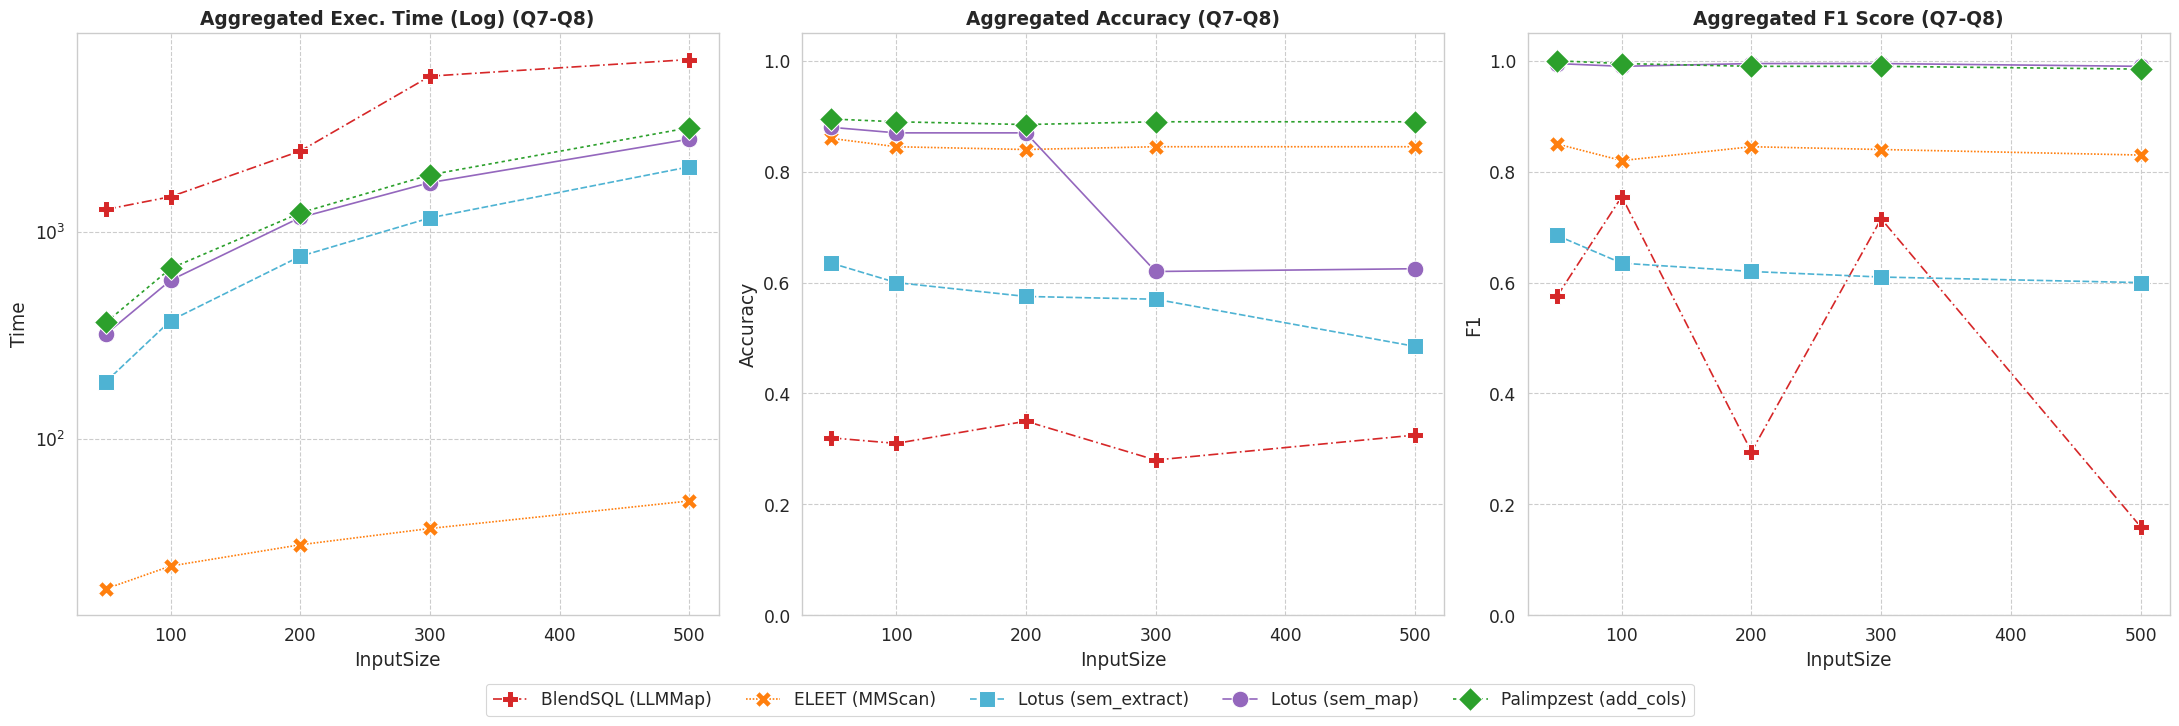

In [ ]:
# DERIVATION
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 1. GLOBAL STYLING CONFIGURATION
# ==========================================
# Dash sequence: (1, 0) is solid, (4, 1.5) is dashed
STYLE_MAP = {
    "Lotus (sem_map)":       {"color": "#9467bd", "marker": "o", "dash": (None, None)},        # solid line (no dash)
    "Lotus (sem_extract)":   {"color": "#4eb3d3", "marker": "s", "dash": (4, 1.5)},           # dashed
    "Palimpzest (sem_add_column)": {"color": "#2ca02c", "marker": "D", "dash": (2, 2)},             # dotted
    "BlendSQL (LLMMap)":     {"color": "#d62728", "marker": "P", "dash": (6, 2, 1, 2)},       # dash-dot-dot
    "ELEET (MMScan)":        {"color": "#ff7f0e", "marker": "X", "dash": (1, 1)},             # densely dotted
}


def get_style_params(labels):
    labels = sorted(list(labels))
    palette = {l: STYLE_MAP[l]["color"] for l in labels if l in STYLE_MAP}
    markers = {l: STYLE_MAP[l]["marker"] for l in labels if l in STYLE_MAP}
    dashes = {l: STYLE_MAP[l]["dash"] for l in labels if l in STYLE_MAP}
    return palette, markers, dashes

# Set global visual context
sns.set_context("paper", font_scale=1.4)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

# ==========================================
# 2. DATA LOADING (Q1-Q8)
# ==========================================
data_1_6 = [
    ["Q1", "Lotus", "sem_map", 50, 15.92, 0.71], ["Q1", "Lotus", "sem_map", 100, 25.98, 0.64], ["Q1", "Lotus", "sem_map", 200, 61.93, 0.57], ["Q1", "Lotus", "sem_map", 300, 91.12, 0.52], ["Q1", "Lotus", "sem_map", 500, 132.00, 0.37],
    ["Q1", "Lotus", "sem_extract", 50, 4.96, 0.71], ["Q1", "Lotus", "sem_extract", 100, 8.27, 0.64], ["Q1", "Lotus", "sem_extract", 200, 17.49, 0.58], ["Q1", "Lotus", "sem_extract", 300, 23.95, 0.53], ["Q1", "Lotus", "sem_extract", 500, 38.70, 0.38],
    ["Q1", "Palimpzest", "sem_add_column", 50, 53.46, 0.67], ["Q1", "Palimpzest", "sem_add_column", 100, 95.07, 0.62], ["Q1", "Palimpzest", "sem_add_column", 200, 221.50, 0.56], ["Q1", "Palimpzest", "sem_add_column", 300, 275.17, 0.51], ["Q1", "Palimpzest", "sem_add_column", 500, 444.43, 0.37],
    ["Q1", "BlendSQL", "LLMMap", 50, 25.97, 0.60], ["Q1", "BlendSQL", "LLMMap", 100, 65.49, 0.53], ["Q1", "BlendSQL", "LLMMap", 200, 71.32, 0.47], ["Q1", "BlendSQL", "LLMMap", 300, 107.55, 0.45], ["Q1", "BlendSQL", "LLMMap", 500, 295.20, 0.30],
    ["Q2", "Lotus", "sem_map", 50, 5.44, 0.66], ["Q2", "Lotus", "sem_map", 100, 8.71, 0.68], ["Q2", "Lotus", "sem_map", 200, 13.02, 0.68], ["Q2", "Lotus", "sem_map", 300, 15.94, 0.69], ["Q2", "Lotus", "sem_map", 500, 31.60, 0.72],
    ["Q2", "BlendSQL", "LLMMap", 50, 10.97, 0.46], ["Q2", "BlendSQL", "LLMMap", 100, 18.01, 0.62], ["Q2", "BlendSQL", "LLMMap", 200, 270.40, 0.30], ["Q2", "BlendSQL", "LLMMap", 300, 40.17, 0.06], ["Q2", "BlendSQL", "LLMMap", 500, 281.75, 0.05],
    ["Q3", "Lotus", "sem_map", 50, 29.11, 0.88], ["Q3", "Lotus", "sem_map", 100, 85.20, 0.10], ["Q3", "Lotus", "sem_map", 200, 143.76, 0.88], ["Q3", "Lotus", "sem_map", 300, 198.36, 0.87], ["Q3", "Lotus", "sem_map", 500, 288.03, 0.87],
    ["Q3", "Lotus", "sem_extract", 50, 20.61, 0.17], ["Q3", "Lotus", "sem_extract", 100, 38.19, 0.10], ["Q3", "Lotus", "sem_extract", 200, 76.95, 0.06], ["Q3", "Lotus", "sem_extract", 300, 114.73, 0.05], ["Q3", "Lotus", "sem_extract", 500, 182.36, 0.04],
    ["Q3", "Palimpzest", "sem_add_column", 50, 54.77, 0.90], ["Q3", "Palimpzest", "sem_add_column", 100, 82.38, 0.90], ["Q3", "Palimpzest", "sem_add_column", 200, 174.79, 0.91], ["Q3", "Palimpzest", "sem_add_column", 300, 260.63, 0.89], ["Q3", "Palimpzest", "sem_add_column", 500, 422.58, 0.89],
    ["Q3", "BlendSQL", "LLMMap", 50, 39.70, 0.35], ["Q3", "BlendSQL", "LLMMap", 100, 59.69, 0.16], ["Q3", "BlendSQL", "LLMMap", 200, 236.87, 0.11], ["Q3", "BlendSQL", "LLMMap", 300, 106.85, 0.08], ["Q3", "BlendSQL", "LLMMap", 500, 308.09, 0.08],
    ["Q4", "Lotus", "sem_map", 50, 56.04, 0.87], ["Q4", "Lotus", "sem_map", 100, 105.14, 0.89], ["Q4", "Lotus", "sem_map", 200, 211.34, 0.88], ["Q4", "Lotus", "sem_map", 300, 320.37, 0.87], ["Q4", "Lotus", "sem_map", 500, 525.63, 0.86],
    ["Q4", "Lotus", "sem_extract", 50, 38.15, 0.85], ["Q4", "Lotus", "sem_extract", 100, 77.24, 0.90], ["Q4", "Lotus", "sem_extract", 200, 156.35, 0.88], ["Q4", "Lotus", "sem_extract", 300, 228.31, 0.88], ["Q4", "Lotus", "sem_extract", 500, 384.47, 0.88],
    ["Q4", "Palimpzest", "sem_add_column", 50, 67.35, 0.92], ["Q4", "Palimpzest", "sem_add_column", 100, 122.02, 0.95], ["Q4", "Palimpzest", "sem_add_column", 200, 239.00, 0.95], ["Q4", "Palimpzest", "sem_add_column", 300, 354.00, 0.96], ["Q4", "Palimpzest", "sem_add_column", 500, 591.39, 0.96],
    ["Q4", "BlendSQL", "LLMMap", 50, 163.92, 0.61], ["Q4", "BlendSQL", "LLMMap", 100, 376.88, 0.56], ["Q4", "BlendSQL", "LLMMap", 200, 446.07, 0.55], ["Q4", "BlendSQL", "LLMMap", 300, 559.78, 0.52], ["Q4", "BlendSQL", "LLMMap", 500, 913.36, 0.51],
    ["Q5", "Lotus", "sem_map", 50, 5.80, 0.57], ["Q5", "Lotus", "sem_map", 100, 9.54, 0.58], ["Q5", "Lotus", "sem_map", 200, 18.14, 0.56], ["Q5", "Lotus", "sem_map", 300, 28.81, 0.57], ["Q5", "Lotus", "sem_map", 500, 32.39, 0.57],
    ["Q5", "BlendSQL", "LLMMap", 50, 28.18, 0.53], ["Q5", "BlendSQL", "LLMMap", 100, 26.58, 0.50], ["Q5", "BlendSQL", "LLMMap", 200, 56.26, 0.55], ["Q5", "BlendSQL", "LLMMap", 300, 67.23, 0.49], ["Q5", "BlendSQL", "LLMMap", 500, 72.53, 0.50],
    ["Q6", "Lotus", "sem_map", 50, 19.18, 0.91], ["Q6", "Lotus", "sem_map", 100, 42.21, 0.90], ["Q6", "Lotus", "sem_map", 200, 88.74, 0.89], ["Q6", "Lotus", "sem_map", 300, 130.42, 0.89], ["Q6", "Lotus", "sem_map", 500, 212.42, 0.89],
    ["Q6", "Lotus", "sem_extract", 50, 23.72, 0.17], ["Q6", "Lotus", "sem_extract", 100, 45.30, 0.13], ["Q6", "Lotus", "sem_extract", 200, 115.33, 0.08], ["Q6", "Lotus", "sem_extract", 300, 162.15, 0.08], ["Q6", "Lotus", "sem_extract", 500, 244.53, 0.07],
    ["Q6", "Palimpzest", "sem_add_column", 50, 61.85, 0.91], ["Q6", "Palimpzest", "sem_add_column", 100, 107.19, 0.88], ["Q6", "Palimpzest", "sem_add_column", 200, 242.33, 0.88], ["Q6", "Palimpzest", "sem_add_column", 300, 311.36, 0.89], ["Q6", "Palimpzest", "sem_add_column", 500, 502.61, 0.90],
    ["Q6", "BlendSQL", "LLMMap", 50, 120.44, 0.11], ["Q6", "BlendSQL", "LLMMap", 100, 242.98, 0.12], ["Q6", "BlendSQL", "LLMMap", 200, 453.40, 0.11], ["Q6", "BlendSQL", "LLMMap", 300, 460.19, 0.12], ["Q6", "BlendSQL", "LLMMap", 500, 797.71, 0.12],
]
df1 = pd.DataFrame(data_1_6, columns=["Query", "System", "Operator", "InputSize", "Time", "Accuracy"])
df1["Label"] = df1["System"] + " (" + df1["Operator"] + ")"

data_7_8 = [
    ["Q7", "Lotus", "sem_map", 50, 552.77, 1.00, 0.88], ["Q7", "Lotus", "sem_map", 100, 993.76, 1.00, 0.87], ["Q7", "Lotus", "sem_map", 200, 2000.09, 1.00, 0.87], ["Q7", "Lotus", "sem_map", 300, 2944.63, 1.00, 0.68], ["Q7", "Lotus", "sem_map", 500, 4774.96, 1.00, 0.68],
    ["Q7", "Lotus", "sem_extract", 50, 325.53, 1.00, 0.95], ["Q7", "Lotus", "sem_extract", 100, 635.13, 0.99, 0.94], ["Q7", "Lotus", "sem_extract", 200, 1269.23, 0.99, 0.94], ["Q7", "Lotus", "sem_extract", 300, 1893.17, 0.99, 0.94], ["Q7", "Lotus", "sem_extract", 500, 3193.82, 0.99, 0.76],
    ["Q7", "Palimpzest", "sem_add_column", 50, 560.28, 1.00, 0.96], ["Q7", "Palimpzest", "sem_add_column", 100, 1004.26, 1.00, 0.95], ["Q7", "Palimpzest", "sem_add_column", 200, 1827.41, 1.00, 0.95], ["Q7", "Palimpzest", "sem_add_column", 300, 2790.05, 1.00, 0.95], ["Q7", "Palimpzest", "sem_add_column", 500, 4805.79, 1.00, 0.95],
    ["Q7", "BlendSQL", "LLMMap", 50, 1823.89, 0.95, 0.46], ["Q7", "BlendSQL", "LLMMap", 100, 2427.90, 0.94, 0.45], ["Q7", "BlendSQL", "LLMMap", 200, 3046.68, 0.08, 0.58], ["Q7", "BlendSQL", "LLMMap", 300, 7305.57, 0.84, 0.46], ["Q7", "BlendSQL", "LLMMap", 500, 9062.82, 0.13, 0.50],
    ["Q7", "ELEET", "MMScan", 50, 20.60, 0.83, 0.83], ["Q7", "ELEET", "MMScan", 100, 26.45, 0.81, 0.82], ["Q7", "ELEET", "MMScan", 200, 37.19, 0.81, 0.81], ["Q7", "ELEET", "MMScan", 300, 47.33, 0.82, 0.82], ["Q7", "ELEET", "MMScan", 500, 66.82, 0.81, 0.82],
    ["Q8", "Lotus", "sem_map", 50, 89.09, 0.99, 0.88], ["Q8", "Lotus", "sem_map", 100, 175.56, 0.98, 0.87], ["Q8", "Lotus", "sem_map", 200, 351.76, 0.99, 0.87], ["Q8", "Lotus", "sem_map", 300, 522.03, 0.99, 0.56], ["Q8", "Lotus", "sem_map", 500, 851.00, 0.98, 0.57],
    ["Q8", "Lotus", "sem_extract", 50, 51.76, 0.37, 0.32], ["Q8", "Lotus", "sem_extract", 100, 111.15, 0.28, 0.26], ["Q8", "Lotus", "sem_extract", 200, 257.47, 0.25, 0.21], ["Q8", "Lotus", "sem_extract", 300, 447.67, 0.23, 0.20], ["Q8", "Lotus", "sem_extract", 500, 940.20, 0.21, 0.21],
    ["Q8", "Palimpzest", "sem_add_column", 50, 170.22, 1.00, 0.83], ["Q8", "Palimpzest", "sem_add_column", 100, 329.60, 0.99, 0.83], ["Q8", "Palimpzest", "sem_add_column", 200, 648.29, 0.98, 0.82], ["Q8", "Palimpzest", "sem_add_column", 300, 991.81, 0.98, 0.83], ["Q8", "Palimpzest", "sem_add_column", 500, 1584.21, 0.97, 0.83],
    ["Q8", "BlendSQL", "LLMMap", 50, 747.19, 0.20, 0.18], ["Q8", "BlendSQL", "LLMMap", 100, 535.47, 0.57, 0.17], ["Q8", "BlendSQL", "LLMMap", 200, 1884.79, 0.51, 0.12], ["Q8", "BlendSQL", "LLMMap", 300, 4043.17, 0.59, 0.10], ["Q8", "BlendSQL", "LLMMap", 500, 4594.27, 0.19, 0.15],
    ["Q8", "ELEET", "MMScan", 50, 16.98, 0.87, 0.89], ["Q8", "ELEET", "MMScan", 100, 22.01, 0.83, 0.87], ["Q8", "ELEET", "MMScan", 200, 24.22, 0.88, 0.87], ["Q8", "ELEET", "MMScan", 300, 26.30, 0.86, 0.87], ["Q8", "ELEET", "MMScan", 500, 33.21, 0.85, 0.87],
]
df2 = pd.DataFrame(data_7_8, columns=["Query", "System", "Operator", "InputSize", "Time", "F1", "Accuracy"])
df2["Label"] = df2["System"] + " (" + df2["Operator"] + ")"

# ==========================================
# CASE 1: Q1-Q6 Individual (4x3 Grid)
# ==========================================
print("Generating individual plots for Q1-Q6...")
palette, markers, dashes = get_style_params(df1["Label"].unique())
fig, axes = plt.subplots(4, 3, figsize=(16, 15), sharex=True)
queries = ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6"]

for idx, q in enumerate(queries):
    col = idx % 3
    row_offset = 0 if idx < 3 else 2
    q_df = df1[df1["Query"] == q]
    
    # Execution Time
    sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", style="Label", 
                 palette=palette, markers=markers, dashes=dashes, markersize=8, 
                 ax=axes[row_offset, col], legend=False)
    axes[row_offset, col].set_title(f"Query {q}", fontweight='bold')
    axes[row_offset, col].set_ylabel("Exec. Time (s)" if col == 0 else "")

    # Accuracy
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
                 palette=palette, markers=markers, dashes=dashes, markersize=8, 
                 ax=axes[row_offset + 1, col], legend=(idx == 0)) # Legend only for handles extraction
    axes[row_offset + 1, col].set_ylim(0, 1.05)
    axes[row_offset + 1, col].set_ylabel("Accuracy" if col == 0 else "")
    if row_offset == 2: axes[row_offset + 1, col].set_xlabel("Input Size")

handles, labels = axes[1, 0].get_legend_handles_labels()
axes[1, 0].get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=4, frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ==========================================
# CASE 2: Q1-Q6 Aggregated (1x2 Grid)
# ==========================================
print("Generating aggregated plots for Q1-Q6...")
agg_df1 = df1.groupby(["Label", "InputSize"])[["Time", "Accuracy"]].mean().reset_index()
palette, markers, dashes = get_style_params(agg_df1["Label"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for ax, y_val, title, ylabel in zip([ax1, ax2], ["Time", "Accuracy"], ["Exec. Time", "Accuracy"], ["Mean Time (s)", "Mean Accuracy"]):
    sns.lineplot(data=agg_df1, x="InputSize", y=y_val, hue="Label", style="Label", 
                 palette=palette, markers=markers, dashes=dashes, markersize=12, ax=ax, legend=(ax == ax2))
    ax.set_title(f"Aggregated {title} (Q1-Q6)", fontweight='bold')
    ax.set_ylabel(ylabel)
    if y_val == "Accuracy": ax.set_ylim(0, 1.05)

handles, labels = ax2.get_legend_handles_labels()
ax2.get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=True)
plt.tight_layout()
plt.show()

# ==========================================
# CASE 3: Q7-Q8 Individual (3x2 Grid)
# ==========================================
print("Generating individual plots for Q7-Q8...")
palette, markers, dashes = get_style_params(df2["Label"].unique())
fig, axes = plt.subplots(3, 2, figsize=(12, 13), sharex=True)
queries = ["Q7", "Q8"]

for i, q in enumerate(queries):
    q_df = df2[df2["Query"] == q]
    for row, metric in enumerate(["Time", "Accuracy", "F1"]):
        ax = axes[row, i]
        sns.lineplot(data=q_df, x="InputSize", y=metric, hue="Label", style="Label", 
                     palette=palette, markers=markers, dashes=dashes, markersize=10, 
                     ax=ax, legend=(i == 0 and row == 0))
        if row == 0: 
            ax.set_yscale('log')
            ax.set_title(f"Query {q} Performance", fontweight='bold')
            ax.set_ylabel("Time (s) - Log Scale" if i == 0 else "")
        else:
            ax.set_ylim(0, 1.05)
            ax.set_ylabel(metric if i == 0 else "")
        if row == 2: ax.set_xlabel("Input Size")

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ==========================================
# CASE 4: Q7-Q8 Aggregated (1x3 Grid)
# ==========================================
print("Generating aggregated plots for Q7-Q8...")
agg_df2 = df2.groupby(["Label", "InputSize"])[["Time", "Accuracy", "F1"]].mean().reset_index()
palette, markers, dashes = get_style_params(agg_df2["Label"].unique())

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
metrics = ["Time", "Accuracy", "F1"]
titles = ["Exec. Time (Log)", "Accuracy", "F1 Score"]

for ax, metric, title in zip(axes, metrics, titles):
    sns.lineplot(data=agg_df2, x="InputSize", y=metric, hue="Label", style="Label", 
                 palette=palette, markers=markers, dashes=dashes, markersize=12, ax=ax, legend=(metric == "F1"))
    ax.set_title(f"Aggregated {title} (Q7-Q8)", fontweight='bold')
    if metric == "Time": ax.set_yscale('log')
    else: ax.set_ylim(0, 1.05)

handles, labels = axes[2].get_legend_handles_labels()
axes[2].get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=5, frameon=True)
plt.tight_layout()
plt.show()

Generating Individual Plots for Q9-Q12...


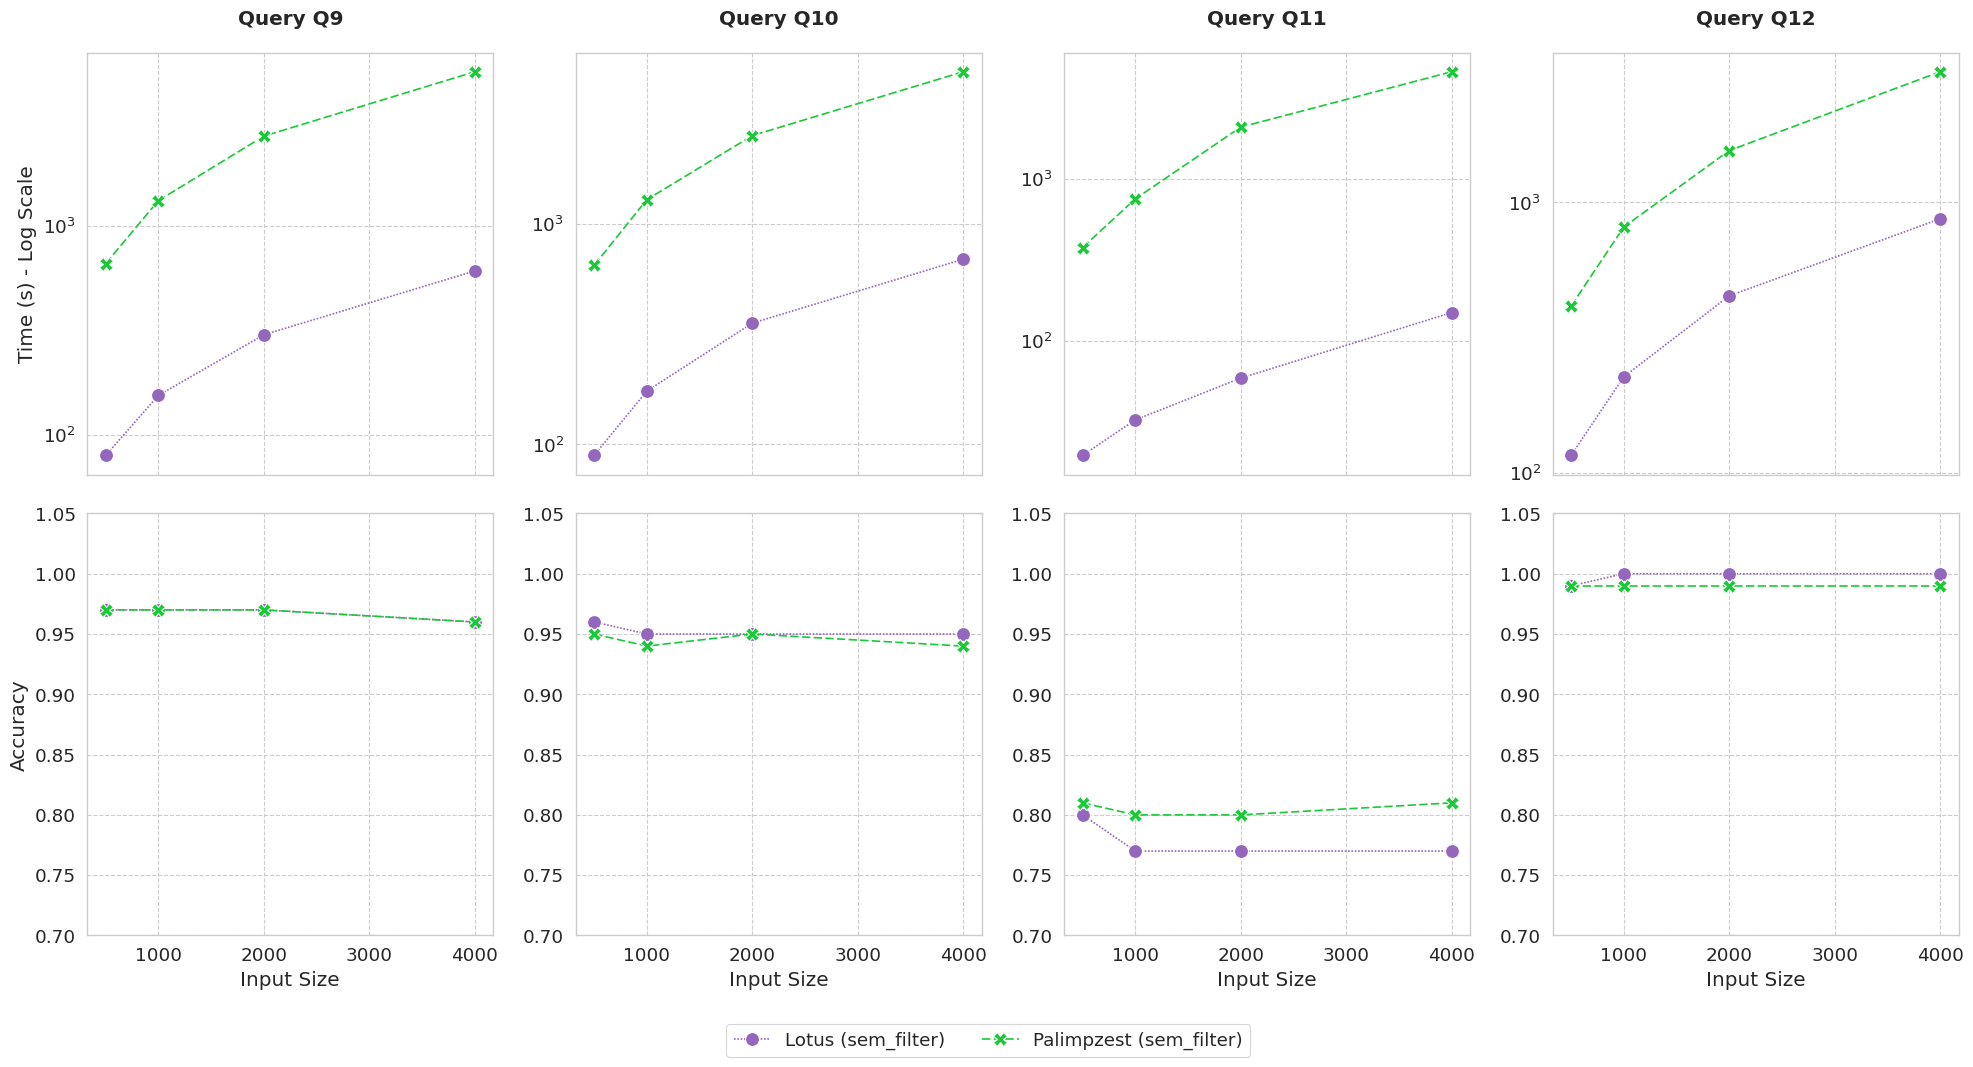

Generating Aggregated Plots for Q9-Q12...


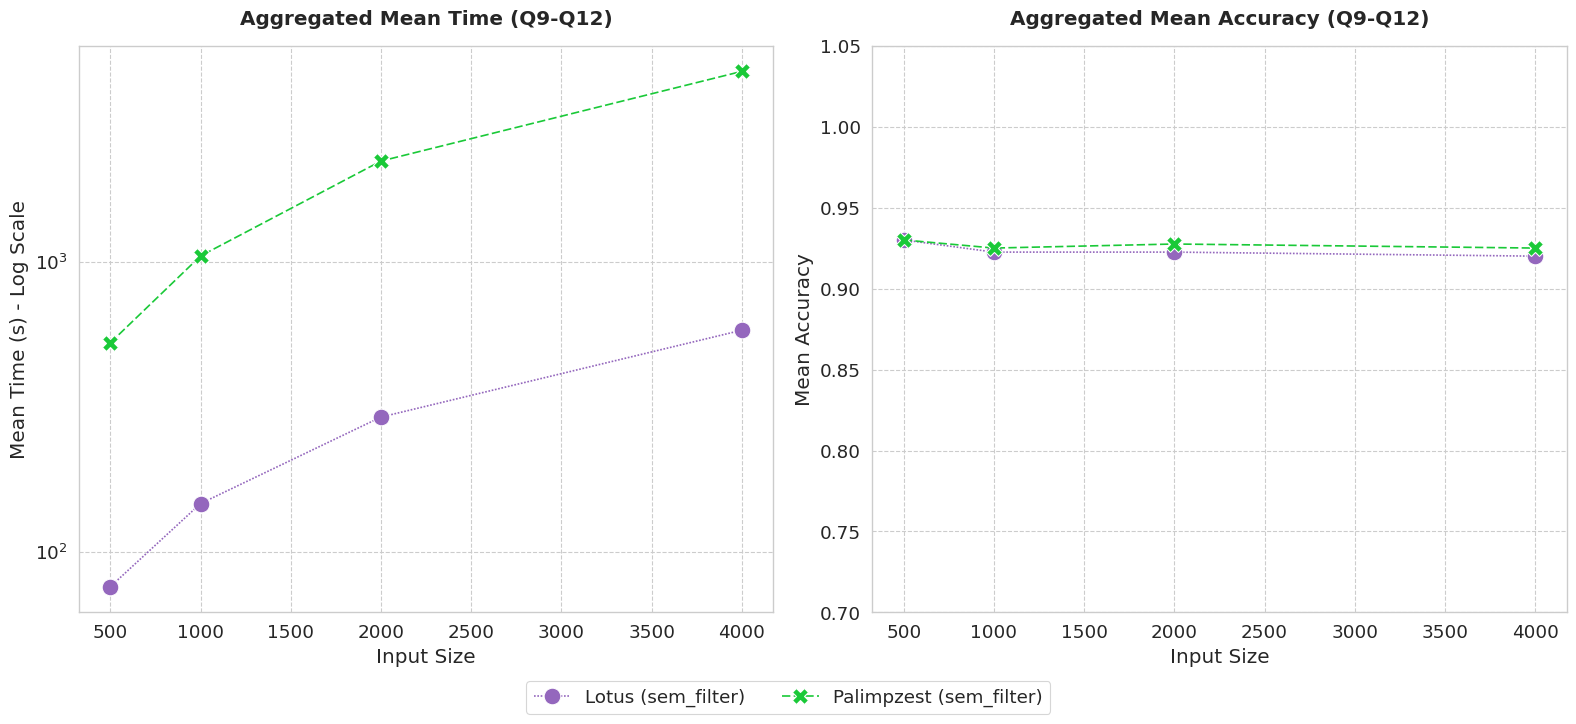

In [ ]:
# SELECTION

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 1. GLOBAL STYLING CONFIGURATION
# ==========================================
bright = sns.color_palette("bright")

# Identity Map: Color, Marker, and Dash (1,0=Solid, 4,1.5=Dashed, 1,1=Dotted)
STYLE_MAP = {
    "Lotus (sem_filter)":      {"color": "#9467bd", "dash": (1, 1),   "marker": "o"}, # Purple, Dotted, Pentagon
    "Palimpzest (sem_filter)": {"color": bright[2], "dash": (5, 2), "marker": "X"}, # Green, Dashed, X
}

def get_style_params(labels):
    """Returns exactly 3 items: palette, markers, dashes"""
    labels = sorted(list(labels))
    palette = {l: STYLE_MAP[l]["color"] for l in labels if l in STYLE_MAP}
    markers = {l: STYLE_MAP[l]["marker"] for l in labels if l in STYLE_MAP}
    dashes = {l: STYLE_MAP[l]["dash"] for l in labels if l in STYLE_MAP}
    return palette, markers, dashes

# Global plot context
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

# ==========================================
# 2. DATA PREPARATION (Q9 - Q12)
# ==========================================
data = [
    # Query | System | Operator | Size | Time | Accuracy
    ["Q9", "Lotus", "sem_filter", 500, 79.68, 0.97], ["Q9", "Lotus", "sem_filter", 1000, 154.51, 0.97], ["Q9", "Lotus", "sem_filter", 2000, 301.67, 0.97], ["Q9", "Lotus", "sem_filter", 4000, 610.44, 0.96],
    ["Q9", "Palimpzest", "sem_filter", 500, 661.65, 0.97], ["Q9", "Palimpzest", "sem_filter", 1000, 1326.53, 0.97], ["Q9", "Palimpzest", "sem_filter", 2000, 2702.59, 0.97], ["Q9", "Palimpzest", "sem_filter", 4000, 5501.64, 0.96],
    ["Q10", "Lotus", "sem_filter", 500, 89.04, 0.96], ["Q10", "Lotus", "sem_filter", 1000, 174.54, 0.95], ["Q10", "Lotus", "sem_filter", 2000, 355.07, 0.95], ["Q10", "Lotus", "sem_filter", 4000, 692.52, 0.95],
    ["Q10", "Palimpzest", "sem_filter", 500, 649.63, 0.95], ["Q10", "Palimpzest", "sem_filter", 1000, 1291.57, 0.94], ["Q10", "Palimpzest", "sem_filter", 2000, 2522.18, 0.95], ["Q10", "Palimpzest", "sem_filter", 4000, 4918.18, 0.94],
    ["Q11", "Lotus", "sem_filter", 500, 19.58, 0.80], ["Q11", "Lotus", "sem_filter", 1000, 32.48, 0.77], ["Q11", "Lotus", "sem_filter", 2000, 58.79, 0.77], ["Q11", "Lotus", "sem_filter", 4000, 149.59, 0.77],
    ["Q11", "Palimpzest", "sem_filter", 500, 377.09, 0.81], ["Q11", "Palimpzest", "sem_filter", 1000, 753.90, 0.80], ["Q11", "Palimpzest", "sem_filter", 2000, 2093.14, 0.80], ["Q11", "Palimpzest", "sem_filter", 4000, 4602.97, 0.81],
    ["Q12", "Lotus", "sem_filter", 500, 115.81, 0.99], ["Q12", "Lotus", "sem_filter", 1000, 226.21, 1.00], ["Q12", "Lotus", "sem_filter", 2000, 451.06, 1.00], ["Q12", "Lotus", "sem_filter", 4000, 869.83, 1.00],
    ["Q12", "Palimpzest", "sem_filter", 500, 413.28, 0.99], ["Q12", "Palimpzest", "sem_filter", 1000, 810.65, 0.99], ["Q12", "Palimpzest", "sem_filter", 2000, 1555.74, 0.99], ["Q12", "Palimpzest", "sem_filter", 4000, 3045.36, 0.99],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# ==========================================
# 3. INDIVIDUAL GRAPHS (2x4 GRID)
# ==========================================
print("Generating Individual Plots for Q9-Q12...")
palette, markers, dashes = get_style_params(df["Label"].unique())
fig, axes = plt.subplots(2, 4, figsize=(20, 11), sharex=True)
queries = ["Q9", "Q10", "Q11", "Q12"]

for i, q in enumerate(queries):
    q_df = df[df["Query"] == q]
    
    # ROW 0: TIME (LOG SCALE)
    ax_time = axes[0, i]
    sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", style="Label", 
                 palette=palette, dashes=dashes, markers=markers, markersize=10, 
                 ax=ax_time, legend=(i==0))
    ax_time.set_yscale('log')
    ax_time.set_title(f"Query {q}", fontweight='bold', pad=20)
    ax_time.set_ylabel("Time (s) - Log Scale" if i == 0 else "")

    # ROW 1: ACCURACY
    ax_acc = axes[1, i]
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
                 palette=palette, dashes=dashes, markers=markers, markersize=10, 
                 ax=ax_acc, legend=False)
    ax_acc.set_ylim(0.7, 1.05)
    ax_acc.set_ylabel("Accuracy" if i == 0 else "")
    ax_acc.set_xlabel("Input Size")

# Shared Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

# ==========================================
# 4. AGGREGATED GRAPHS (1x2 GRID)
# ==========================================
print("Generating Aggregated Plots for Q9-Q12...")
agg_df = df.groupby(["Label", "InputSize"])[["Time", "Accuracy"]].mean().reset_index()
palette, markers, dashes = get_style_params(agg_df["Label"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Aggregated Time
sns.lineplot(data=agg_df, x="InputSize", y="Time", hue="Label", style="Label", 
             palette=palette, dashes=dashes, markers=markers, markersize=12, 
             ax=ax1, legend=True)
ax1.set_yscale('log')
ax1.set_title("Aggregated Mean Time (Q9-Q12)", fontweight='bold', pad=15)
ax1.set_ylabel("Mean Time (s) - Log Scale")
ax1.set_xlabel("Input Size")

# Aggregated Accuracy
sns.lineplot(data=agg_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
             palette=palette, dashes=dashes, markers=markers, markersize=12, 
             ax=ax2, legend=False)
ax2.set_ylim(0.7, 1.05)
ax2.set_title("Aggregated Mean Accuracy (Q9-Q12)", fontweight='bold', pad=15)
ax2.set_ylabel("Mean Accuracy")
ax2.set_xlabel("Input Size")

# Shared Legend
handles, labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

Generating Individual Plots for Q9-Q12...


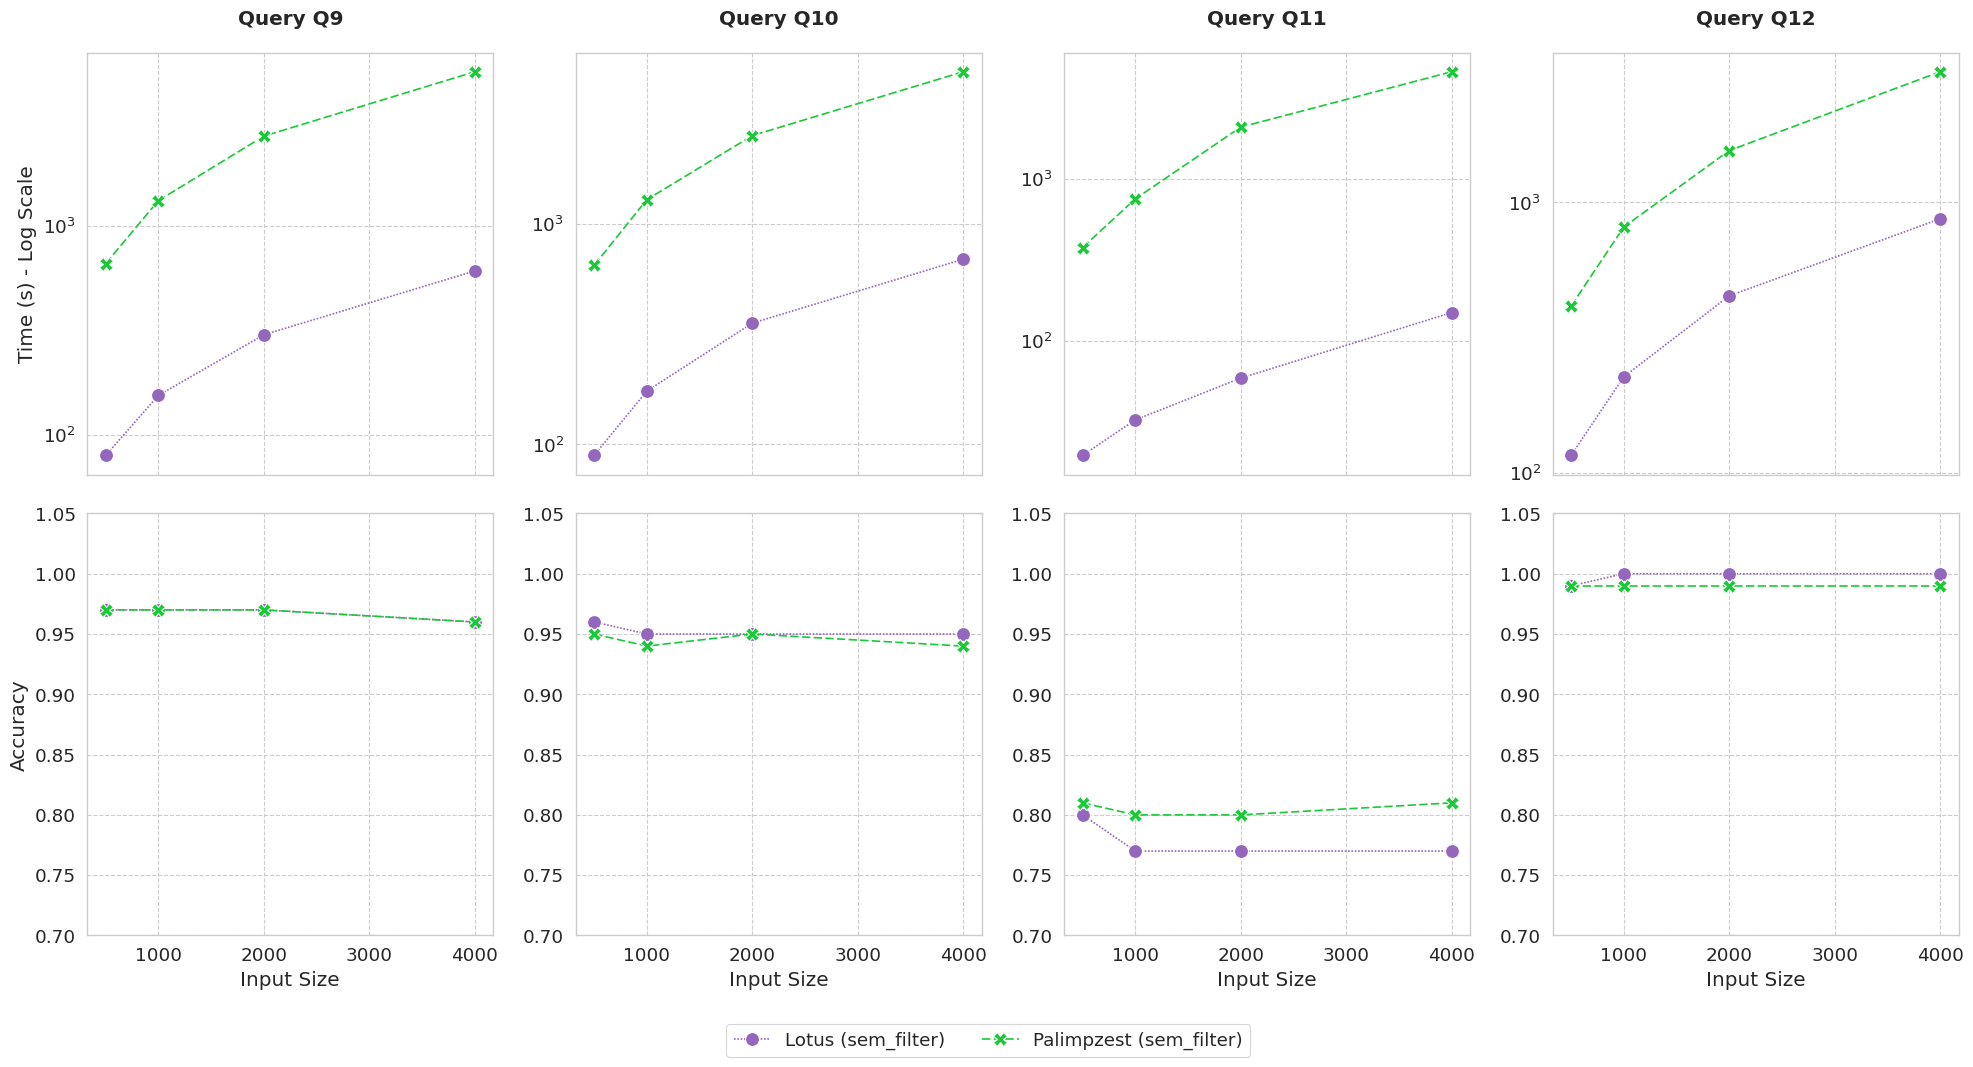

Generating Aggregated Plots for Q9-Q12...


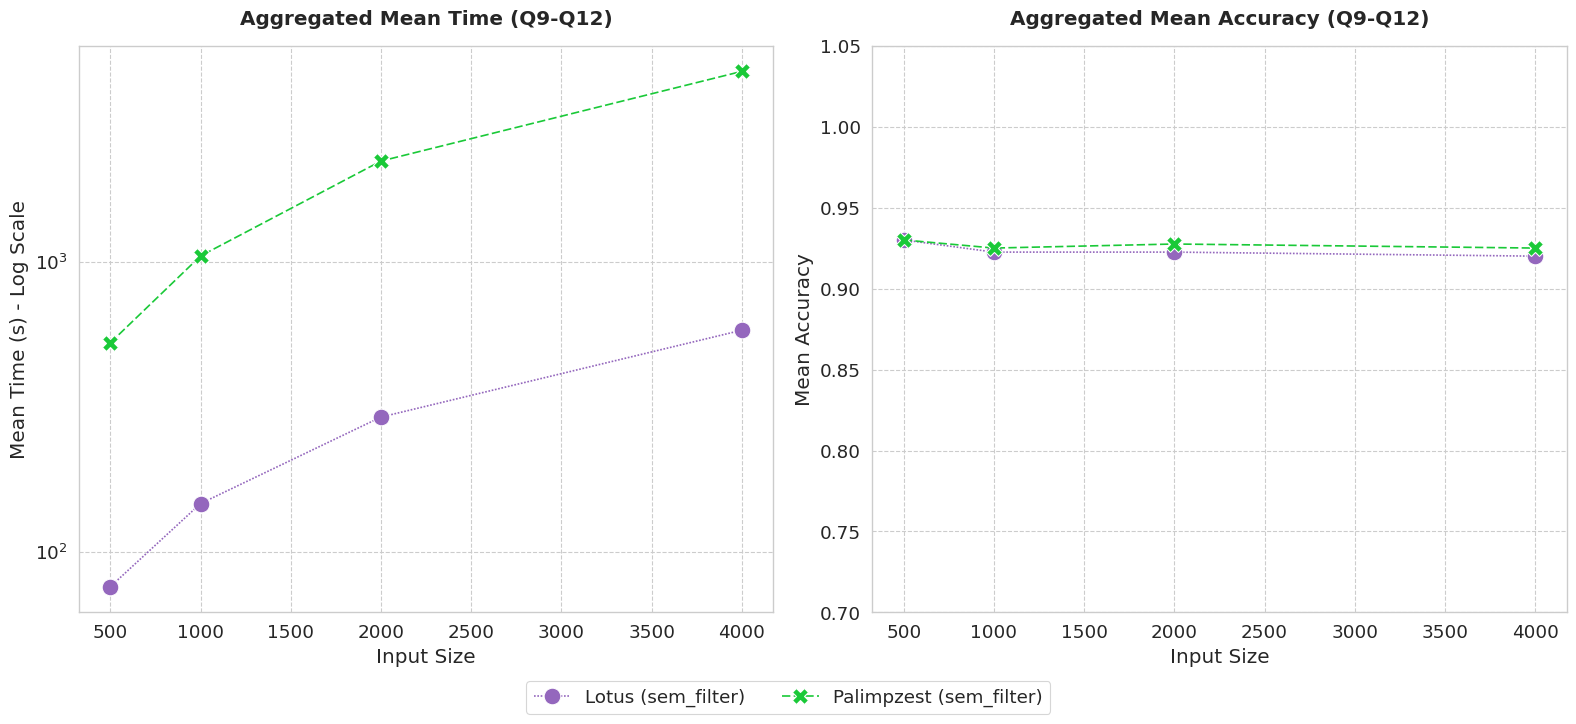

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 1. GLOBAL STYLING CONFIGURATION
# ==========================================
bright = sns.color_palette("bright")

# Identity Map: Color, Marker, and Dash (1,0=Solid, 4,1.5=Dashed, 1,1=Dotted)
STYLE_MAP = {
    "Lotus (sem_filter)":      {"color": "#9467bd", "dash": (1, 1),   "marker": "o"}, # Purple, Dotted, Pentagon
    "Palimpzest (sem_filter)": {"color": bright[2], "dash": (5, 2), "marker": "X"}, # Green, Dashed, X
}

def get_style_params(labels):
    """Returns exactly 3 items: palette, markers, dashes"""
    labels = sorted(list(labels))
    palette = {l: STYLE_MAP[l]["color"] for l in labels if l in STYLE_MAP}
    markers = {l: STYLE_MAP[l]["marker"] for l in labels if l in STYLE_MAP}
    dashes = {l: STYLE_MAP[l]["dash"] for l in labels if l in STYLE_MAP}
    return palette, markers, dashes

# Global plot context
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

# ==========================================
# 2. DATA PREPARATION (Q9 - Q12)
# ==========================================
data = [
    # Query | System | Operator | Size | Time | Accuracy
    ["Q9", "Lotus", "sem_filter", 500, 79.68, 0.97], ["Q9", "Lotus", "sem_filter", 1000, 154.51, 0.97], ["Q9", "Lotus", "sem_filter", 2000, 301.67, 0.97], ["Q9", "Lotus", "sem_filter", 4000, 610.44, 0.96],
    ["Q9", "Palimpzest", "sem_filter", 500, 661.65, 0.97], ["Q9", "Palimpzest", "sem_filter", 1000, 1326.53, 0.97], ["Q9", "Palimpzest", "sem_filter", 2000, 2702.59, 0.97], ["Q9", "Palimpzest", "sem_filter", 4000, 5501.64, 0.96],
    ["Q10", "Lotus", "sem_filter", 500, 89.04, 0.96], ["Q10", "Lotus", "sem_filter", 1000, 174.54, 0.95], ["Q10", "Lotus", "sem_filter", 2000, 355.07, 0.95], ["Q10", "Lotus", "sem_filter", 4000, 692.52, 0.95],
    ["Q10", "Palimpzest", "sem_filter", 500, 649.63, 0.95], ["Q10", "Palimpzest", "sem_filter", 1000, 1291.57, 0.94], ["Q10", "Palimpzest", "sem_filter", 2000, 2522.18, 0.95], ["Q10", "Palimpzest", "sem_filter", 4000, 4918.18, 0.94],
    ["Q11", "Lotus", "sem_filter", 500, 19.58, 0.80], ["Q11", "Lotus", "sem_filter", 1000, 32.48, 0.77], ["Q11", "Lotus", "sem_filter", 2000, 58.79, 0.77], ["Q11", "Lotus", "sem_filter", 4000, 149.59, 0.77],
    ["Q11", "Palimpzest", "sem_filter", 500, 377.09, 0.81], ["Q11", "Palimpzest", "sem_filter", 1000, 753.90, 0.80], ["Q11", "Palimpzest", "sem_filter", 2000, 2093.14, 0.80], ["Q11", "Palimpzest", "sem_filter", 4000, 4602.97, 0.81],
    ["Q12", "Lotus", "sem_filter", 500, 115.81, 0.99], ["Q12", "Lotus", "sem_filter", 1000, 226.21, 1.00], ["Q12", "Lotus", "sem_filter", 2000, 451.06, 1.00], ["Q12", "Lotus", "sem_filter", 4000, 869.83, 1.00],
    ["Q12", "Palimpzest", "sem_filter", 500, 413.28, 0.99], ["Q12", "Palimpzest", "sem_filter", 1000, 810.65, 0.99], ["Q12", "Palimpzest", "sem_filter", 2000, 1555.74, 0.99], ["Q12", "Palimpzest", "sem_filter", 4000, 3045.36, 0.99],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# ==========================================
# 3. INDIVIDUAL GRAPHS (2x4 GRID)
# ==========================================
print("Generating Individual Plots for Q9-Q12...")
palette, markers, dashes = get_style_params(df["Label"].unique())
fig, axes = plt.subplots(2, 4, figsize=(20, 11), sharex=True)
queries = ["Q9", "Q10", "Q11", "Q12"]

for i, q in enumerate(queries):
    q_df = df[df["Query"] == q]
    
    # ROW 0: TIME (LOG SCALE)
    ax_time = axes[0, i]
    sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", style="Label", 
                 palette=palette, dashes=dashes, markers=markers, markersize=10, 
                 ax=ax_time, legend=(i==0))
    ax_time.set_yscale('log')
    ax_time.set_title(f"Query {q}", fontweight='bold', pad=20)
    ax_time.set_ylabel("Time (s) - Log Scale" if i == 0 else "")

    # ROW 1: ACCURACY
    ax_acc = axes[1, i]
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
                 palette=palette, dashes=dashes, markers=markers, markersize=10, 
                 ax=ax_acc, legend=False)
    ax_acc.set_ylim(0.7, 1.05)
    ax_acc.set_ylabel("Accuracy" if i == 0 else "")
    ax_acc.set_xlabel("Input Size")

# Shared Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

# ==========================================
# 4. AGGREGATED GRAPHS (1x2 GRID)
# ==========================================
print("Generating Aggregated Plots for Q9-Q12...")
agg_df = df.groupby(["Label", "InputSize"])[["Time", "Accuracy"]].mean().reset_index()
palette, markers, dashes = get_style_params(agg_df["Label"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Aggregated Time
sns.lineplot(data=agg_df, x="InputSize", y="Time", hue="Label", style="Label", 
             palette=palette, dashes=dashes, markers=markers, markersize=12, 
             ax=ax1, legend=True)
ax1.set_yscale('log')
ax1.set_title("Aggregated Mean Time (Q9-Q12)", fontweight='bold', pad=15)
ax1.set_ylabel("Mean Time (s) - Log Scale")
ax1.set_xlabel("Input Size")

# Aggregated Accuracy
sns.lineplot(data=agg_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
             palette=palette, dashes=dashes, markers=markers, markersize=12, 
             ax=ax2, legend=False)
ax2.set_ylim(0.7, 1.05)
ax2.set_title("Aggregated Mean Accuracy (Q9-Q12)", fontweight='bold', pad=15)
ax2.set_ylabel("Mean Accuracy")
ax2.set_xlabel("Input Size")

# Shared Legend
handles, labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

Generating Individual Plots for Q9-Q12 Optimized...


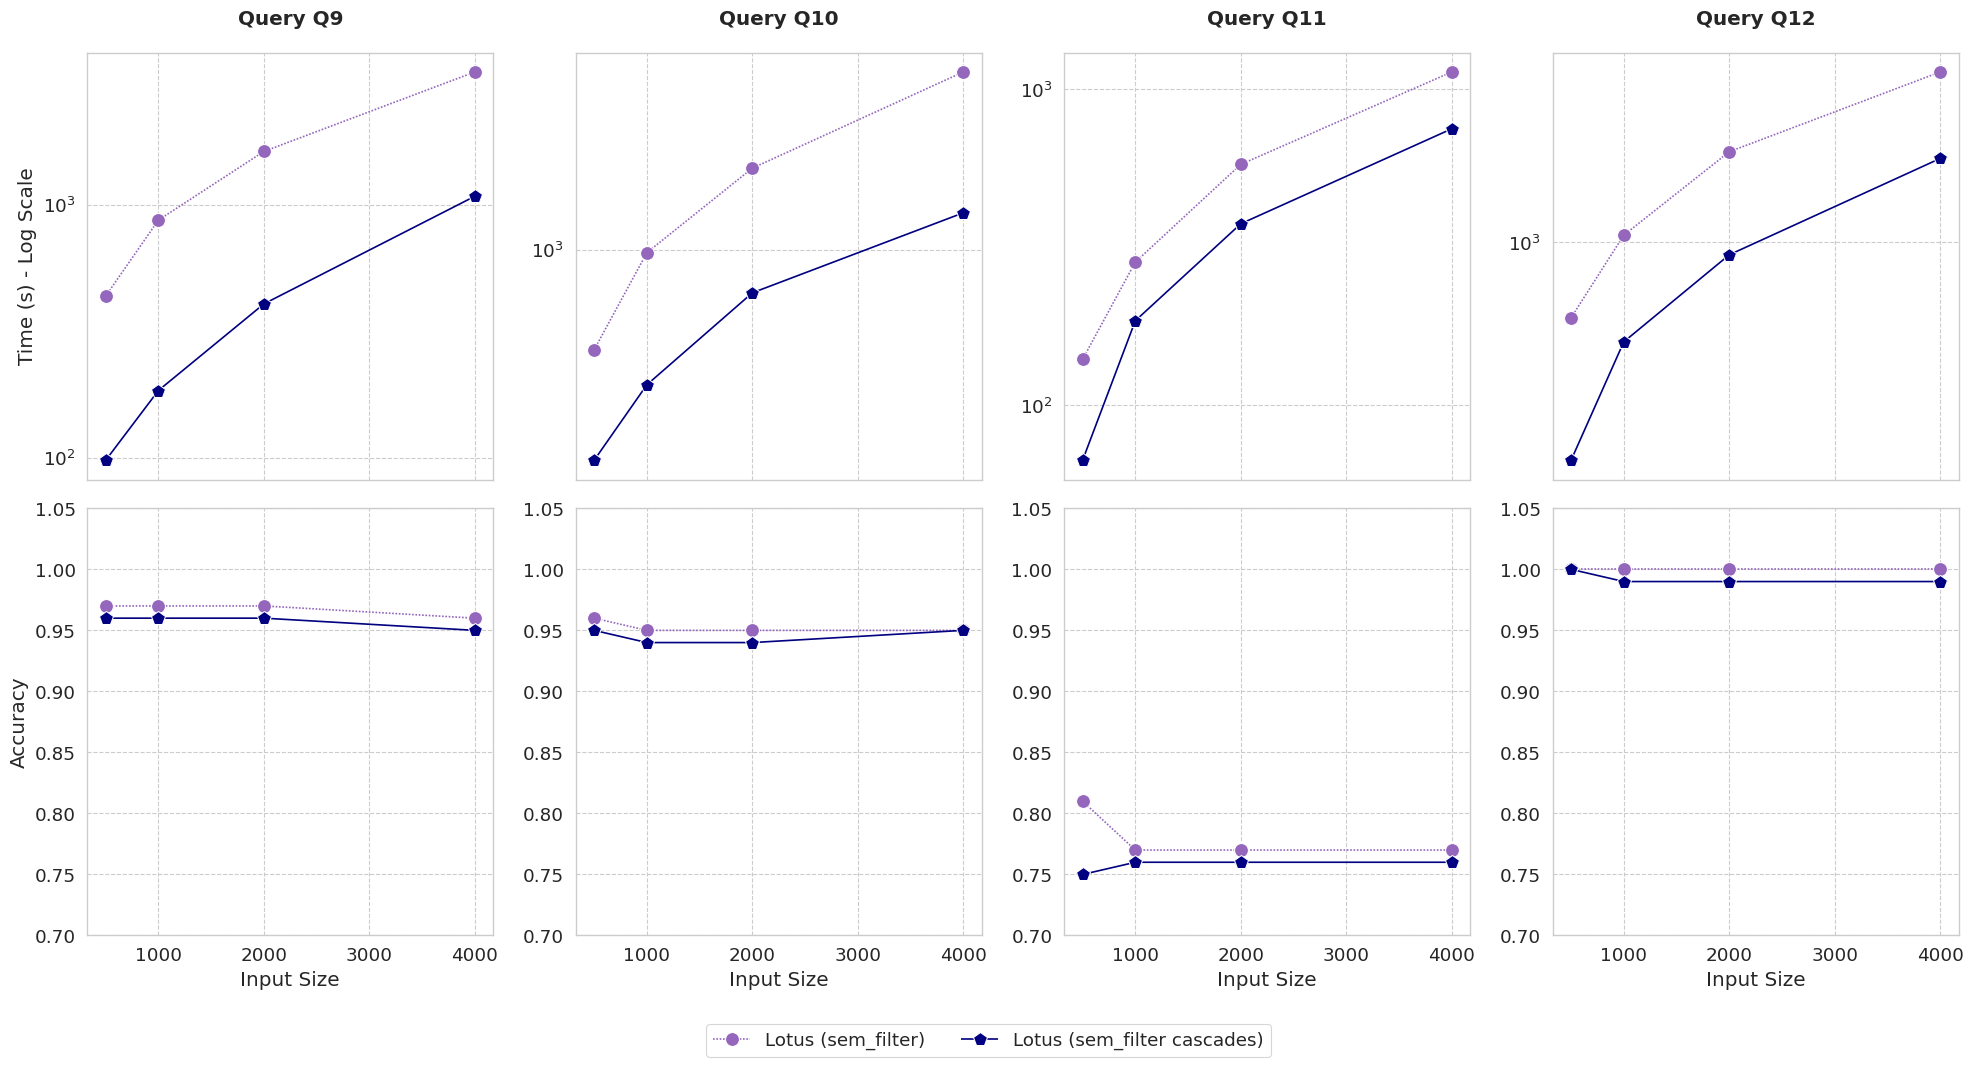

Generating Aggregated Plots for Q9-Q12 Optimized...


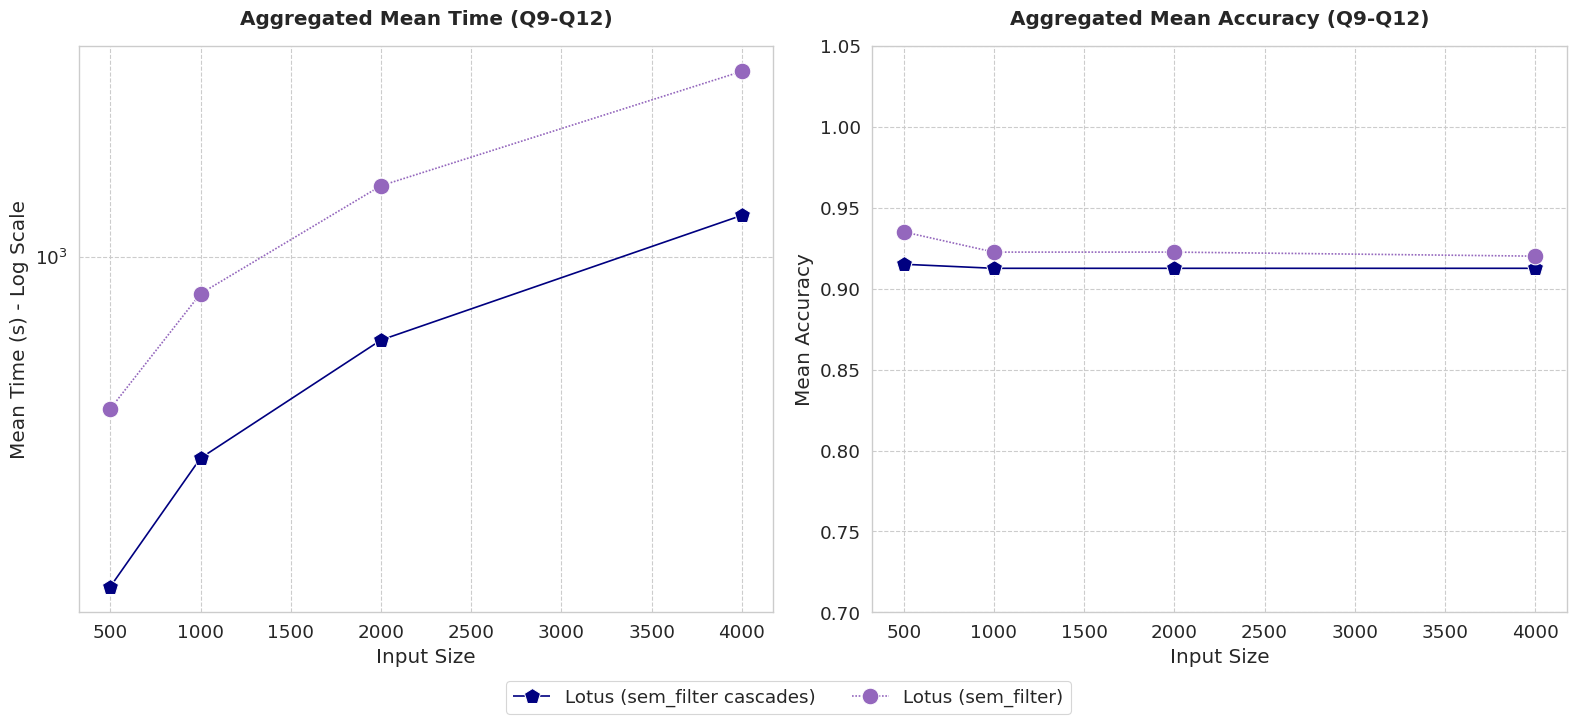

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 1. GLOBAL STYLING CONFIGURATION
# ==========================================
bright = sns.color_palette("bright")

# Identity Map: Colors, Markers, and Dashes
# Cascades (Optimized) is Solid Navy, Default is Dotted Purple
STYLE_MAP = {
    "Lotus (sem_filter)":            {"color": "#9467bd", "dash": (1, 1),   "marker": "o"}, # Purple, Dotted
    "Lotus (sem_filter cascades)":   {"color": "#000080", "dash": (1, 0),   "marker": "p"}, # Navy, Solid
}

def get_style_params(labels):
    labels = sorted(list(labels))
    palette = {l: STYLE_MAP[l]["color"] for l in labels if l in STYLE_MAP}
    markers = {l: STYLE_MAP[l]["marker"] for l in labels if l in STYLE_MAP}
    dashes = {l: STYLE_MAP[l]["dash"] for l in labels if l in STYLE_MAP}
    return palette, markers, dashes

# Global plot context
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

# ==========================================
# 2. DATA PREPARATION (Q9 - Q12 Optimized)
# ==========================================
data = [
    # Query | System | Operator | Size | Time | Accuracy
    ["Q9", "Lotus", "sem_filter", 500, 435.81, 0.97], ["Q9", "Lotus", "sem_filter", 1000, 870.68, 0.97], ["Q9", "Lotus", "sem_filter", 2000, 1627.54, 0.97], ["Q9", "Lotus", "sem_filter", 4000, 3357.97, 0.96],
    ["Q9", "Lotus", "sem_filter cascades", 500, 97.56, 0.96], ["Q9", "Lotus", "sem_filter cascades", 1000, 184.28, 0.96], ["Q9", "Lotus", "sem_filter cascades", 2000, 405.68, 0.96], ["Q9", "Lotus", "sem_filter cascades", 4000, 1081.91, 0.95],
    
    ["Q10", "Lotus", "sem_filter", 500, 468.25, 0.96], ["Q10", "Lotus", "sem_filter", 1000, 980.01, 0.95], ["Q10", "Lotus", "sem_filter", 2000, 1863.45, 0.95], ["Q10", "Lotus", "sem_filter", 4000, 3872.65, 0.95],
    ["Q10", "Lotus", "sem_filter cascades", 500, 202.11, 0.95], ["Q10", "Lotus", "sem_filter cascades", 1000, 358.87, 0.94], ["Q10", "Lotus", "sem_filter cascades", 2000, 722.11, 0.94], ["Q10", "Lotus", "sem_filter cascades", 4000, 1326.90, 0.95],

    ["Q11", "Lotus", "sem_filter", 500, 139.89, 0.81], ["Q11", "Lotus", "sem_filter", 1000, 284.32, 0.77], ["Q11", "Lotus", "sem_filter", 2000, 579.48, 0.77], ["Q11", "Lotus", "sem_filter", 4000, 1136.28, 0.77],
    ["Q11", "Lotus", "sem_filter cascades", 500, 67.05, 0.75], ["Q11", "Lotus", "sem_filter cascades", 1000, 185.40, 0.76], ["Q11", "Lotus", "sem_filter cascades", 2000, 375.88, 0.76], ["Q11", "Lotus", "sem_filter cascades", 4000, 750.91, 0.76],

    ["Q12", "Lotus", "sem_filter", 500, 536.89, 1.00], ["Q12", "Lotus", "sem_filter", 1000, 1061.76, 1.00], ["Q12", "Lotus", "sem_filter", 2000, 2114.00, 1.00], ["Q12", "Lotus", "sem_filter", 4000, 4084.33, 1.00],
    ["Q12", "Lotus", "sem_filter cascades", 500, 165.57, 1.00], ["Q12", "Lotus", "sem_filter cascades", 1000, 440.22, 0.99], ["Q12", "Lotus", "sem_filter cascades", 2000, 902.93, 0.99], ["Q12", "Lotus", "sem_filter cascades", 4000, 2000.31, 0.99],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# ==========================================
# 3. INDIVIDUAL GRAPHS (2x4 GRID)
# ==========================================
print("Generating Individual Plots for Q9-Q12 Optimized...")
palette, markers, dashes = get_style_params(df["Label"].unique())
fig, axes = plt.subplots(2, 4, figsize=(20, 11), sharex=True)
queries = ["Q9", "Q10", "Q11", "Q12"]

for i, q in enumerate(queries):
    q_df = df[df["Query"] == q]
    
    # ROW 0: TIME (LOG SCALE)
    ax_time = axes[0, i]
    sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", style="Label", 
                 palette=palette, dashes=dashes, markers=markers, markersize=10, 
                 ax=ax_time, legend=(i==0))
    ax_time.set_yscale('log')
    ax_time.set_title(f"Query {q}", fontweight='bold', pad=20)
    ax_time.set_ylabel("Time (s) - Log Scale" if i == 0 else "")

    # ROW 1: ACCURACY
    ax_acc = axes[1, i]
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
                 palette=palette, dashes=dashes, markers=markers, markersize=10, 
                 ax=ax_acc, legend=False)
    ax_acc.set_ylim(0.7, 1.05)
    ax_acc.set_ylabel("Accuracy" if i == 0 else "")
    ax_acc.set_xlabel("Input Size")

# Shared Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

# ==========================================
# 4. AGGREGATED GRAPHS (1x2 GRID)
# ==========================================
print("Generating Aggregated Plots for Q9-Q12 Optimized...")
agg_df = df.groupby(["Label", "InputSize"])[["Time", "Accuracy"]].mean().reset_index()
palette, markers, dashes = get_style_params(agg_df["Label"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Aggregated Time
sns.lineplot(data=agg_df, x="InputSize", y="Time", hue="Label", style="Label", 
             palette=palette, dashes=dashes, markers=markers, markersize=12, 
             ax=ax1, legend=True)
ax1.set_yscale('log')
ax1.set_title("Aggregated Mean Time (Q9-Q12)", fontweight='bold', pad=15)
ax1.set_ylabel("Mean Time (s) - Log Scale")
ax1.set_xlabel("Input Size")

# Aggregated Accuracy
sns.lineplot(data=agg_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
             palette=palette, dashes=dashes, markers=markers, markersize=12, 
             ax=ax2, legend=False)
ax2.set_ylim(0.7, 1.05)
ax2.set_title("Aggregated Mean Accuracy (Q9-Q12)", fontweight='bold', pad=15)
ax2.set_ylabel("Mean Accuracy")
ax2.set_xlabel("Input Size")

# Shared Legend
handles, labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

Generating Individual Plots for Q13-Q15...


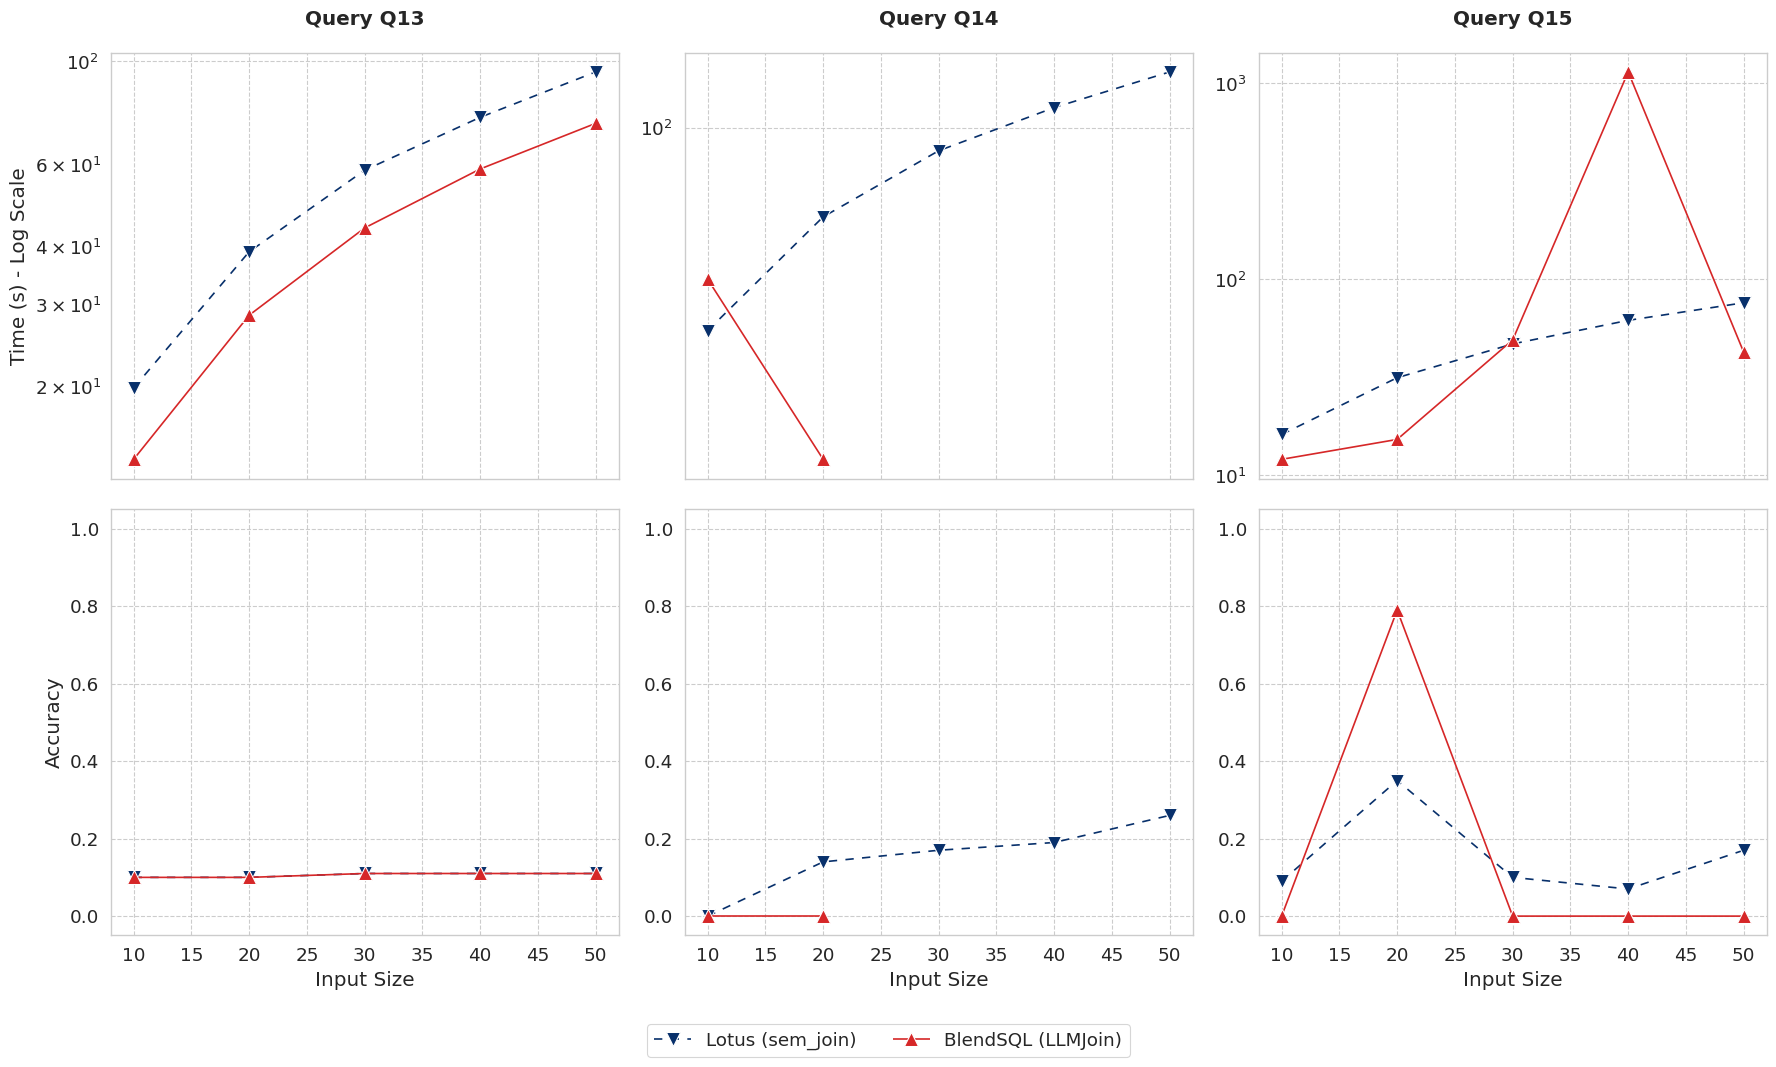

Generating Aggregated Plots for Q13-Q15...


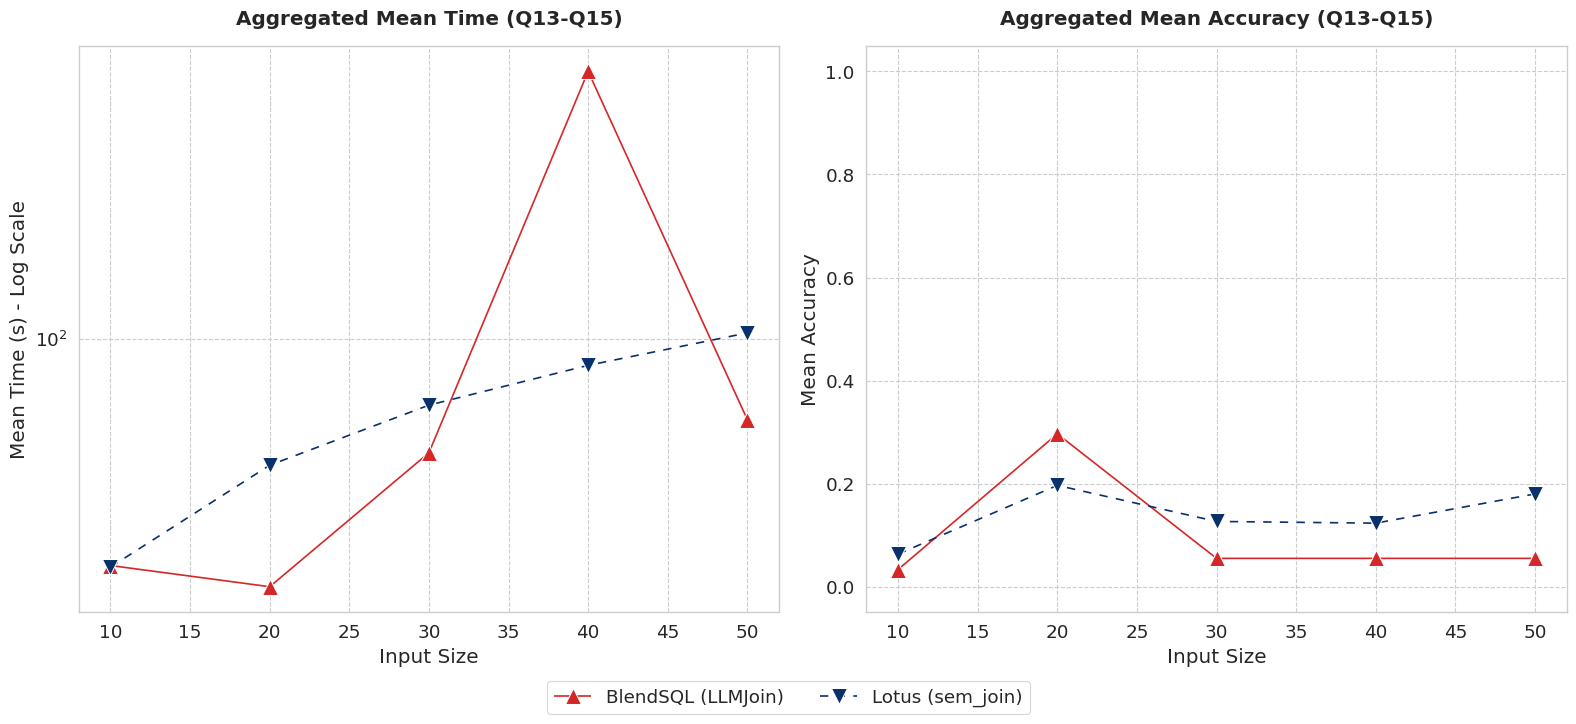

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# ==========================================
# 1. GLOBAL STYLING CONFIGURATION
# ==========================================
bright = sns.color_palette("bright")

# Identity Map: Colors, Markers, and Dashes
# Lotus family: Blue tones | BlendSQL: Red
STYLE_MAP = {
    "Lotus (sem_join)":      {"color": "#08306b", "dash": (5, 5),   "marker": "v"}, # Dark Blue, Long Dash
    "BlendSQL (LLMJoin)":    {"color": "#d62728", "dash": (1, 0),   "marker": "^"}, # Red, Solid
}

def get_style_params(labels):
    """Returns exactly 3 items: palette, markers, dashes"""
    labels = sorted(list(labels))
    palette = {l: STYLE_MAP[l]["color"] for l in labels if l in STYLE_MAP}
    markers = {l: STYLE_MAP[l]["marker"] for l in labels if l in STYLE_MAP}
    dashes = {l: STYLE_MAP[l]["dash"] for l in labels if l in STYLE_MAP}
    return palette, markers, dashes

# Global plot context
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

# ==========================================
# 2. DATA PREPARATION (Q13 - Q15)
# ==========================================
data = [
    # Q13 - Banking Data
    ["Q13", "Lotus", "sem_join", 10, 19.83, 0.10], ["Q13", "Lotus", "sem_join", 20, 38.94, 0.10], ["Q13", "Lotus", "sem_join", 30, 58.32, 0.11], ["Q13", "Lotus", "sem_join", 40, 75.79, 0.11], ["Q13", "Lotus", "sem_join", 50, 94.91, 0.11],
    ["Q13", "BlendSQL", "LLMJoin", 10, 13.93, 0.10], ["Q13", "BlendSQL", "LLMJoin", 20, 28.44, 0.10], ["Q13", "BlendSQL", "LLMJoin", 30, 43.82, 0.11], ["Q13", "BlendSQL", "LLMJoin", 40, 58.68, 0.11], ["Q13", "BlendSQL", "LLMJoin", 50, 73.56, 0.11],

    # Q14 - DeepScholar-Bench (Updated Lotus to sem_join)
    ["Q14", "Lotus", "sem_join", 10, 28.71, 0.00], ["Q14", "Lotus", "sem_join", 20, 57.77, 0.14], ["Q14", "Lotus", "sem_join", 30, 86.72, 0.17], ["Q14", "Lotus", "sem_join", 40, 113.06, 0.19], ["Q14", "Lotus", "sem_join", 50, 140.78, 0.26],
    ["Q14", "BlendSQL", "LLMJoin", 10, 39.39, 0.00], ["Q14", "BlendSQL", "LLMJoin", 20, 13.02, 0.00], ["Q14", "BlendSQL", "LLMJoin", 30, np.nan, np.nan], ["Q14", "BlendSQL", "LLMJoin", 40, np.nan, np.nan], ["Q14", "BlendSQL", "LLMJoin", 50, np.nan, np.nan],
    
    # Q15 - IMDB Movies (Updated Lotus to sem_join)
    ["Q15", "Lotus", "sem_join", 10, 16.16, 0.09], ["Q15", "Lotus", "sem_join", 20, 31.49, 0.35], ["Q15", "Lotus", "sem_join", 30, 46.83, 0.10], ["Q15", "Lotus", "sem_join", 40, 61.78, 0.07], ["Q15", "Lotus", "sem_join", 50, 75.95, 0.17],
    ["Q15", "BlendSQL", "LLMJoin", 10, 12.07, 0.00], ["Q15", "BlendSQL", "LLMJoin", 20, 15.25, 0.79], ["Q15", "BlendSQL", "LLMJoin", 30, 49.09, 0.00], ["Q15", "BlendSQL", "LLMJoin", 40, 1143.74, 0.00], ["Q15", "BlendSQL", "LLMJoin", 50, 42.50, 0.00],
]

df = pd.DataFrame(data, columns=["Query", "System", "Operator", "InputSize", "Time", "Accuracy"])
df["Label"] = df["System"] + " (" + df["Operator"] + ")"

# ==========================================
# 3. INDIVIDUAL GRAPHS (2x3 GRID)
# ==========================================
print("Generating Individual Plots for Q13-Q15...")
palette, markers, dashes = get_style_params(df["Label"].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharex=True)
queries = ["Q13", "Q14", "Q15"]

for i, q in enumerate(queries):
    q_df = df[df["Query"] == q]
    
    # ROW 0: TIME (LOG SCALE due to Q15 spike)
    ax_time = axes[0, i]
    sns.lineplot(data=q_df, x="InputSize", y="Time", hue="Label", style="Label", 
                 palette=palette, dashes=dashes, markers=markers, markersize=10, 
                 ax=ax_time, legend=(i==0))
    ax_time.set_yscale('log')
    ax_time.set_title(f"Query {q}", fontweight='bold', pad=20)
    ax_time.set_ylabel("Time (s) - Log Scale" if i == 0 else "")

    # ROW 1: ACCURACY
    ax_acc = axes[1, i]
    sns.lineplot(data=q_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
                 palette=palette, dashes=dashes, markers=markers, markersize=10, 
                 ax=ax_acc, legend=False)
    ax_acc.set_ylim(-0.05, 1.05)
    ax_acc.set_ylabel("Accuracy" if i == 0 else "")
    ax_acc.set_xlabel("Input Size")

# Shared Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

# ==========================================
# 4. AGGREGATED GRAPHS (1x2 GRID)
# ==========================================
print("Generating Aggregated Plots for Q13-Q15...")
agg_df = df.groupby(["Label", "InputSize"])[["Time", "Accuracy"]].mean().reset_index()
palette, markers, dashes = get_style_params(agg_df["Label"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Aggregated Time
sns.lineplot(data=agg_df, x="InputSize", y="Time", hue="Label", style="Label", 
             palette=palette, dashes=dashes, markers=markers, markersize=12, 
             ax=ax1, legend=True)
ax1.set_yscale('log')
ax1.set_title("Aggregated Mean Time (Q13-Q15)", fontweight='bold', pad=15)
ax1.set_ylabel("Mean Time (s) - Log Scale")
ax1.set_xlabel("Input Size")

# Aggregated Accuracy
sns.lineplot(data=agg_df, x="InputSize", y="Accuracy", hue="Label", style="Label", 
             palette=palette, dashes=dashes, markers=markers, markersize=12, 
             ax=ax2, legend=False)
ax2.set_ylim(-0.05, 1.05)
ax2.set_title("Aggregated Mean Accuracy (Q13-Q15)", fontweight='bold', pad=15)
ax2.set_ylabel("Mean Accuracy")
ax2.set_xlabel("Input Size")

# Shared Legend
handles, labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=True)

plt.tight_layout()
plt.show()